# Fraud Detection Model Development and Evaluation

## Notebook 2 — Machine Learning Modeling

This notebook develops and evaluates machine learning models for transaction fraud detection using the finalized feature datasets prepared in Notebook 1.

Feature engineering and data preparation are not repeated here. The focus is model development, comparative evaluation, threshold analysis, business-cost assessment, model selection, error analysis, and final model artifact creation.

### Modeling Workflow

The analysis follows this sequence:

1. Load the finalized train, validation, and test datasets.
2. Prepare the configured modeling features and target.
3. Establish baseline performance.
4. Train and compare candidate models.
5. Analyze threshold behavior and business cost.
6. Tune the strongest candidate models.
7. Evaluate probability-based ensemble alternatives.
8. Select and freeze the final production configuration.
9. Evaluate the frozen configuration once on the untouched test set.
10. Analyze prediction errors and save the final model artifact.

### Evaluation Design

The datasets are used chronologically:

- **Training set** — model fitting.
- **Validation set** — model comparison, threshold analysis, tuning, and model selection.
- **Test set** — final unbiased evaluation after the model and production threshold have been frozen.

The test set is not used to make model-development or selection decisions.

## 1. Project Setup

The project root is configured first so the notebook can access the finalized application modules and processed datasets consistently.

All paths are derived from the project structure rather than hard-coded to a local machine.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Processed data directory not found: {PROCESSED_DATA_DIR}"
    )

print(f"Using processed data from: {PROCESSED_DATA_DIR}")

Using processed data from: C:\AI\fraud-risk-intelligence-platform\data\processed


## 2. Modeling and Evaluation Setup

The notebook uses the project's finalized feature, evaluation, threshold, business-cost, error-analysis, and tuning functions.

Only functions required by the modeling workflow are imported.

In [3]:
from app.features.preprocessing import (
    MODEL_FEATURES,
    TARGET_COLUMN,
    prepare_model_data,
)

from app.evaluation.metrics import evaluate_model

from app.evaluation.business import (
    calculate_business_cost,
    analyze_business_thresholds,
)

from app.evaluation.thresholds import (
    DEFAULT_THRESHOLD_GRID,
    analyze_thresholds,
)

from app.evaluation.model_comparison import (
    build_model_comparison,
)

from app.models.tuning import (
    tune_catboost,
    tune_xgboost,
    train_tuned_catboost,
    train_tuned_xgboost,
)

print("Modeling components loaded.")

Modeling components loaded.


## 3. Load Finalized Datasets

Notebook 1 produced the chronological datasets used for model development.

The time periods are:

- **Training:** April–July 2018
- **Validation:** August 2018
- **Test:** September 2018

This chronological separation is preserved throughout model development and evaluation.

In [4]:
train_features_path = PROCESSED_DATA_DIR / "train_features.parquet"
validation_features_path = PROCESSED_DATA_DIR / "validation_features.parquet"
test_features_path = PROCESSED_DATA_DIR / "test_features.parquet"

required_files = {
    "Train": train_features_path,
    "Validation": validation_features_path,
    "Test": test_features_path,
}

missing_files = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        f"Missing processed dataset files: {missing_files}"
    )

train_data = pd.read_parquet(train_features_path)
validation_data = pd.read_parquet(validation_features_path)
test_data = pd.read_parquet(test_features_path)

print("Finalized datasets loaded successfully.")

Finalized datasets loaded successfully.


## 4. Prepare Modeling Data

The finalized datasets are converted into feature matrices and target vectors using the configured modeling schema.

No new feature engineering is performed in this notebook. The same feature definition is applied to the training, validation, and test sets.

In [5]:
X_train, y_train = prepare_model_data(train_data)
X_validation, y_validation = prepare_model_data(validation_data)
X_test, y_test = prepare_model_data(test_data)

model_data_summary = pd.DataFrame(
    {
        "dataset": ["Train", "Validation", "Test"],
        "records": [
            len(X_train),
            len(X_validation),
            len(X_test),
        ],
        "features": [
            X_train.shape[1],
            X_validation.shape[1],
            X_test.shape[1],
        ],
        "fraud_transactions": [
            int(y_train.sum()),
            int(y_validation.sum()),
            int(y_test.sum()),
        ],
    }
)

display(model_data_summary)

,dataset,records,features,fraud_transactions
0,Train,1169723,23,9465
1,Validation,296559,23,2669
2,Test,287873,23,2547


## 5. Modeling Data Validation

Before fitting any model, the prepared datasets are checked for schema consistency and target integrity.

The checks verify that:

- the configured feature schema is preserved;
- feature columns are consistent across datasets;
- feature matrices and targets remain aligned; and
- the target contains only the expected binary classes.

Model development proceeds only after these checks pass.

In [6]:
modeling_checks = pd.DataFrame(
    {
        "check": [
            "train_features_match_configuration",
            "validation_features_match_configuration",
            "test_features_match_configuration",
            "consistent_feature_columns",
            "train_feature_target_alignment",
            "validation_feature_target_alignment",
            "test_feature_target_alignment",
            "train_target_is_binary",
            "validation_target_is_binary",
            "test_target_is_binary",
        ],
        "result": [
            list(X_train.columns) == MODEL_FEATURES,
            list(X_validation.columns) == MODEL_FEATURES,
            list(X_test.columns) == MODEL_FEATURES,
            (
                list(X_train.columns)
                == list(X_validation.columns)
                == list(X_test.columns)
            ),
            len(X_train) == len(y_train),
            len(X_validation) == len(y_validation),
            len(X_test) == len(y_test),
            set(y_train.unique()).issubset({0, 1}),
            set(y_validation.unique()).issubset({0, 1}),
            set(y_test.unique()).issubset({0, 1}),
        ],
    }
)

display(modeling_checks)

assert modeling_checks["result"].all(), (
    "Modeling readiness checks failed."
)

print(
    "All modeling readiness checks passed."
)

,check,result
0,train_features_match_configuration,True
1,validation_features_match_configuration,True
2,test_features_match_configuration,True
3,consistent_feature_columns,True
4,train_feature_target_alignment,True
5,validation_feature_target_alignment,True
6,test_feature_target_alignment,True
7,train_target_is_binary,True
8,validation_target_is_binary,True
9,test_target_is_binary,True


All modeling readiness checks passed.


## 6. Evaluation Strategy

Fraud detection is an imbalanced binary classification problem, so accuracy alone is not sufficient for model comparison.

The evaluation separates **ranking performance** from **threshold-dependent classification performance**.

### Ranking Metrics

- **ROC-AUC** measures how well the model separates fraudulent and legitimate transactions across probability thresholds.
- **PR-AUC** summarizes the precision-recall trade-off and is especially informative when the positive class is rare.

PR-AUC receives particular attention because fraudulent transactions represent a small proportion of the dataset.

### Classification Metrics

At a selected threshold, the following metrics are reported:

- **Precision** — proportion of flagged transactions that are actually fraudulent.
- **Recall** — proportion of fraudulent transactions detected.
- **F1-score** — harmonic balance between precision and recall.
- **False Positives** — legitimate transactions incorrectly flagged.
- **False Negatives** — fraudulent transactions missed by the model.
- **True Positives / True Negatives** — correctly identified fraud and legitimate transactions.

### Threshold Analysis

A probability threshold converts predicted fraud probabilities into binary decisions.

A threshold of **0.50** is used initially as a common reference point across candidate models. Threshold analysis is then performed on validation data to examine how the operating point affects precision, recall, F1-score, and error volume.

The threshold is treated as a decision parameter rather than an intrinsic property of the model.

### Business Evaluation

Predictive metrics and business cost provide different views of model performance.

False positives create investigation workload, while false negatives represent missed fraud. Business-cost analysis is therefore used to evaluate the operational effect of different thresholds and cost assumptions.

### Dataset Usage

- **Training** — model fitting.
- **Validation** — model comparison, threshold analysis, tuning, and selection.
- **Test** — final evaluation only after the production configuration has been frozen.

## 7. Logistic Regression Baseline

Logistic Regression is used as the initial reference model because it provides a simple and interpretable baseline before evaluating more complex tree-based models.

Class weighting is used because fraudulent transactions are a small minority of the dataset.

The model is first evaluated at the default threshold of 0.50. Threshold and business-cost analysis are then performed separately on the validation set.

### Class Distribution

Fraud represents a small proportion of transactions in each chronological split.

The class distribution is checked before model evaluation so that subsequent precision, recall, PR-AUC, and error counts can be interpreted in the context of class imbalance.

In [7]:
split_targets = {
    "Train": y_train,
    "Validation": y_validation,
    "Test": y_test,
}

class_balance_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "total_transactions": len(target),
            "non_fraud_transactions": int((target == 0).sum()),
            "fraud_transactions": int((target == 1).sum()),
            "fraud_rate_percentage": round(
                target.mean() * 100,
                4,
            ),
        }
        for dataset_name, target in split_targets.items()
    ]
)

display(class_balance_summary)

,dataset,total_transactions,non_fraud_transactions,fraud_transactions,fraud_rate_percentage
0,Train,1169723,1160258,9465,0.8092
1,Validation,296559,293890,2669,0.9000
2,Test,287873,285326,2547,0.8848


### Logistic Regression as a Reference Model

Logistic Regression provides an interpretable reference point for the tree-based models that follow.

Class weighting gives the minority fraud class greater influence during training, while predicted probabilities allow the decision threshold to be analyzed independently of model fitting.

### Logistic Regression Configuration

The baseline uses median imputation, feature standardization, and class-weighted Logistic Regression in a single pipeline.

Keeping these preprocessing steps inside the pipeline ensures that the transformation parameters are learned from the training data only.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_baseline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

### Generate Validation Predictions

The model is fitted using the training set only.

Fraud probabilities are then generated for the validation set. These probabilities are retained so that different decision thresholds can be evaluated without retraining the model.

In [9]:
logistic_baseline.fit(X_train, y_train)

print("Logistic Regression baseline trained.")

Logistic Regression baseline trained.


In [10]:
baseline_validation_probabilities = (
    logistic_baseline.predict_proba(X_validation)[:, 1]
)

baseline_validation_predictions = (
    baseline_validation_probabilities >= 0.50
).astype(int)

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


### Baseline Prediction Summary

In [11]:
baseline_prediction_summary = pd.DataFrame(
    {
        "validation_records": [len(y_validation)],
        "actual_fraud_transactions": [int(y_validation.sum())],
        "predicted_fraud_transactions": [
            int(baseline_validation_predictions.sum())
        ],
        "average_fraud_probability": [
            baseline_validation_probabilities.mean()
        ],
    }
)

display(baseline_prediction_summary)

,validation_records,actual_fraud_transactions,predicted_fraud_transactions,average_fraud_probability
0,296559,2669,24027,0.208125


### Baseline Model Evaluation

The Logistic Regression baseline is evaluated on the validation set using the standardized model evaluation function.

A threshold of 0.50 is used for the initial comparison across models. Threshold analysis is performed separately.

The test set remains untouched at this stage.

In [12]:
baseline_metrics = evaluate_model(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

baseline_metrics_df = pd.DataFrame(
    {
        "metric": baseline_metrics.keys(),
        "value": baseline_metrics.values(),
    }
)

baseline_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.925162
2,roc_auc,0.931600
3,pr_auc,0.177729
4,precision,0.093686
5,recall,0.843387
6,f1_score,0.168639
7,true_negatives,272114.000000
8,false_positives,21776.000000
9,false_negatives,418.000000


### Baseline Performance

The Logistic Regression results establish the initial reference point for subsequent model comparisons.

Because fraud is rare, accuracy is interpreted alongside PR-AUC, ROC-AUC, precision, recall, F1-score, and the confusion-matrix counts.

In [13]:
baseline_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

baseline_summary = (
    baseline_metrics_df[
        baseline_metrics_df["metric"].isin(
            baseline_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

baseline_summary

,metric,value
0,accuracy,0.925162
1,roc_auc,0.931600
2,pr_auc,0.177729
3,precision,0.093686
4,recall,0.843387
5,f1_score,0.168639
6,true_negatives,272114.000000
7,false_positives,21776.000000
8,false_negatives,418.000000
9,true_positives,2251.000000


## 8. Logistic Regression Threshold Analysis

A probability threshold converts predicted fraud probabilities into binary decisions.

The default threshold of 0.50 is only one possible operating point. Lower thresholds generally increase recall but also increase false-positive volume, while higher thresholds reduce alerts at the risk of missing more fraud.

Threshold analysis is performed on the validation set before considering business-cost assumptions.

In [14]:
threshold_results_df = analyze_thresholds(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

threshold_results_df

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.124127,0.9316,0.177729,0.010122,0.995129,0.020041,34155,259735,13,2656
1,0.10,0.346326,0.9316,0.177729,0.013314,0.979768,0.026270,100091,193799,54,2615
2,0.15,0.532471,0.9316,0.177729,0.018177,0.961034,0.035680,155344,138546,104,2565
3,0.20,0.664549,0.9316,0.177729,0.024714,0.943050,0.048165,194561,99329,152,2517
4,0.25,0.755182,0.9316,0.177729,0.033014,0.926190,0.063755,221484,72406,197,2472
5,0.30,0.816279,0.9316,0.177729,0.042747,0.907456,0.081648,239653,54237,247,2422
6,0.35,0.857954,0.9316,0.177729,0.053726,0.889846,0.101333,252059,41831,294,2375
7,0.40,0.887419,0.9316,0.177729,0.065909,0.873735,0.122572,260840,33050,337,2332
8,0.45,0.908956,0.9316,0.177729,0.079383,0.860247,0.145353,267263,26627,373,2296
9,0.50,0.925162,0.9316,0.177729,0.093686,0.843387,0.168639,272114,21776,418,2251


### Threshold Performance Comparison

The same Logistic Regression model is evaluated across multiple probability thresholds.

As the threshold increases, fewer transactions are classified as fraudulent. This generally reduces false-positive volume and increases precision, while increasing the risk of missed fraud.

The purpose of this analysis is to understand the operating trade-off before introducing business-cost assumptions.

In [15]:
threshold_comparison_columns = [
    "threshold",
    "precision",
    "recall",
    "f1_score",
    "false_positives",
    "false_negatives",
    "true_positives",
]

threshold_comparison = (
    threshold_results_df[
        threshold_comparison_columns
    ]
    .copy()
)

threshold_comparison

,threshold,precision,recall,f1_score,false_positives,false_negatives,true_positives
0,0.05,0.010122,0.995129,0.020041,259735,13,2656
1,0.10,0.013314,0.979768,0.026270,193799,54,2615
2,0.15,0.018177,0.961034,0.035680,138546,104,2565
3,0.20,0.024714,0.943050,0.048165,99329,152,2517
4,0.25,0.033014,0.926190,0.063755,72406,197,2472
5,0.30,0.042747,0.907456,0.081648,54237,247,2422
6,0.35,0.053726,0.889846,0.101333,41831,294,2375
7,0.40,0.065909,0.873735,0.122572,33050,337,2332
8,0.45,0.079383,0.860247,0.145353,26627,373,2296
9,0.50,0.093686,0.843387,0.168639,21776,418,2251


### Threshold Validation

The threshold analysis is checked to confirm that:

- the expected thresholds were evaluated;
- thresholds are ordered correctly;
- all thresholds fall within the valid probability range;
- the default threshold is included; and
- changing the threshold produces changes in recall and false-positive volume.

In [16]:
threshold_validation_checks = {
    "all_candidate_thresholds_evaluated": (
        len(threshold_results_df)
        == len(DEFAULT_THRESHOLD_GRID)
    ),
    "thresholds_sorted_in_ascending_order": (
        threshold_results_df["threshold"]
        .is_monotonic_increasing
    ),
    "all_thresholds_between_zero_and_one": (
        threshold_results_df["threshold"]
        .between(0, 1)
        .all()
    ),
    "default_threshold_included": (
        0.50
        in threshold_results_df["threshold"].values
    ),
    "recall_changes_across_thresholds": (
        threshold_results_df["recall"]
        .nunique()
        > 1
    ),
    "false_positive_volume_changes_across_thresholds": (
        threshold_results_df["false_positives"]
        .nunique()
        > 1
    ),
}

threshold_validation_summary = pd.DataFrame(
    {
        "check": threshold_validation_checks.keys(),
        "result": threshold_validation_checks.values(),
    }
)

display(threshold_validation_summary)

assert threshold_validation_summary["result"].all(), (
    "Threshold validation checks failed."
)

,check,result
0,all_candidate_thresholds_evaluated,True
1,thresholds_sorted_in_ascending_order,True
2,all_thresholds_between_zero_and_one,True
3,default_threshold_included,True
4,recall_changes_across_thresholds,True
5,false_positive_volume_changes_across_thresholds,True


### Threshold Trade-off Analysis

The default threshold of 0.50 represents only one operating point.

Comparing multiple thresholds makes the precision-recall and false-positive/false-negative trade-off explicit.

Lower thresholds prioritize fraud capture but generate more alerts. Higher thresholds reduce alerts but increase the risk of missed fraud.

No final production threshold is selected at this stage.

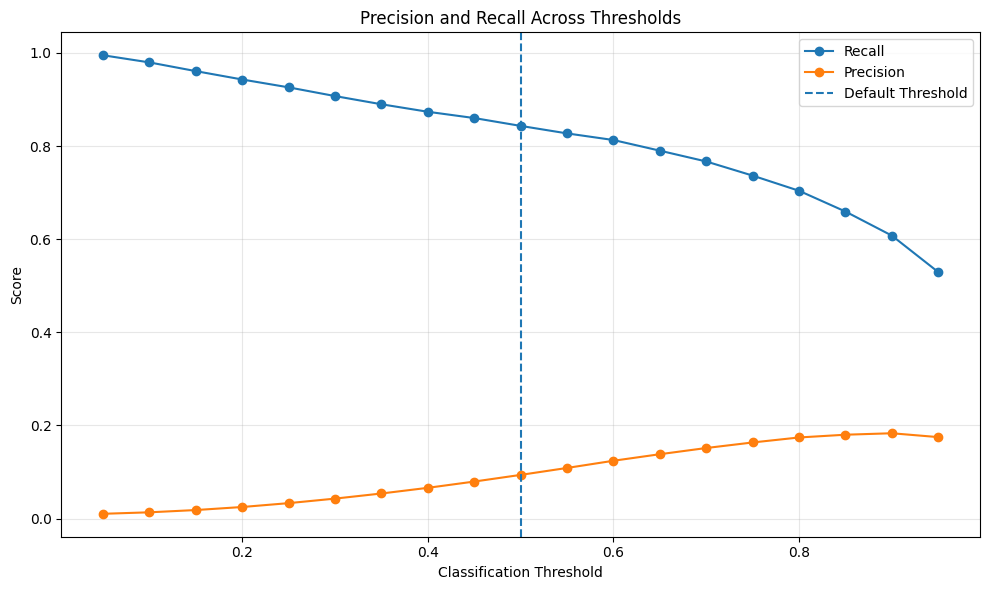

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision",
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Fraud Detection Error Trade-off

False positives are legitimate transactions incorrectly flagged as fraud, while false negatives are fraudulent transactions that the model misses.

These errors have different operational consequences. Threshold analysis helps show how changing the decision threshold shifts the balance between unnecessary alerts and missed fraud.

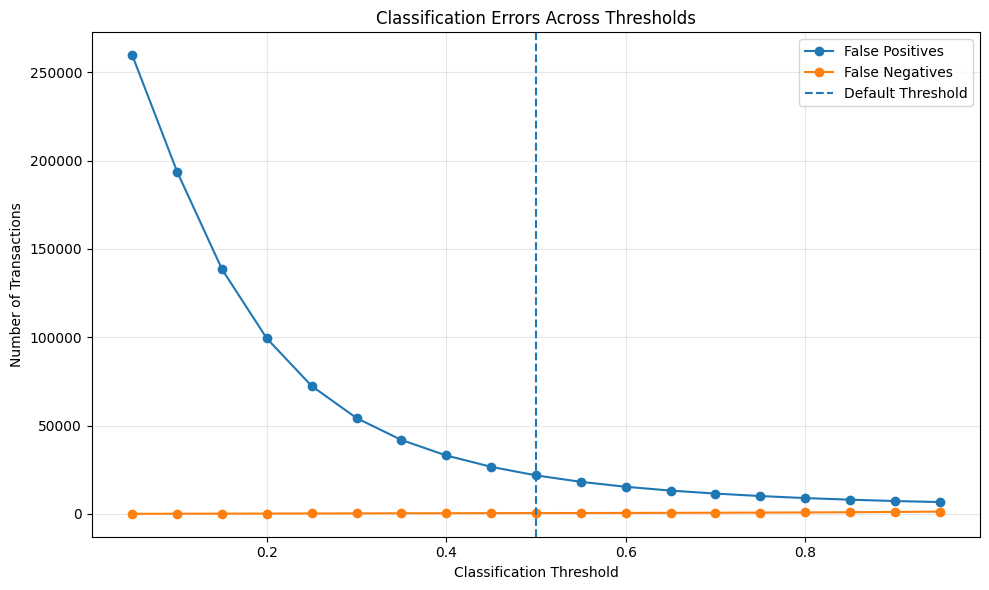

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["false_positives"],
    marker="o",
    label="False Positives",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["false_negatives"],
    marker="o",
    label="False Negatives",
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Transactions")
plt.title("Classification Errors Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### F1-score Analysis

F1-score summarizes the balance between precision and recall and can be useful for identifying strong classification operating points.

However, F1-score alone does not determine the final fraud-detection threshold because business cost and operational constraints also matter.

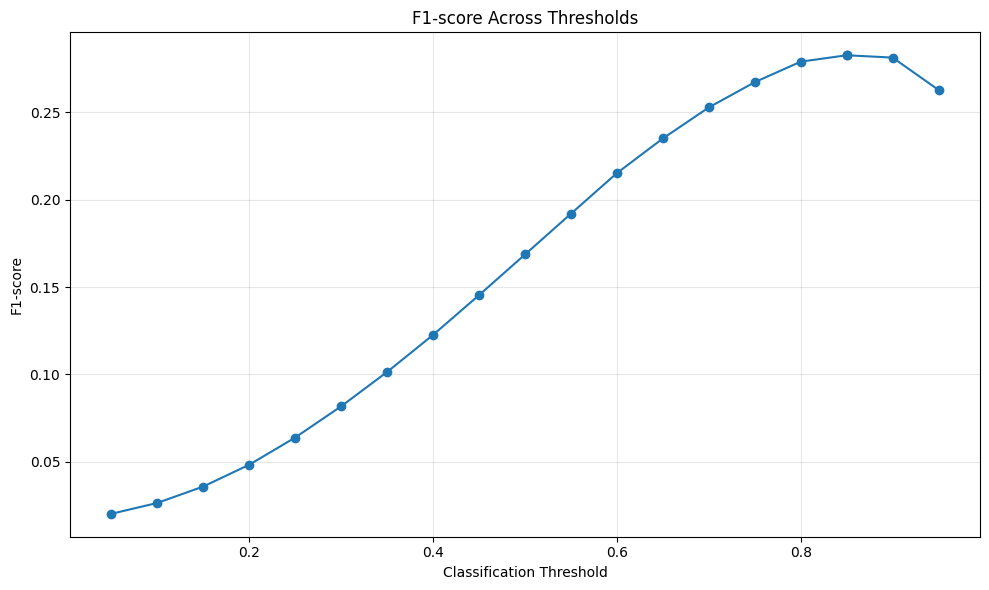

threshold             0.850000
precision             0.179996
recall                0.659423
f1_score              0.282799
false_positives    8018.000000
false_negatives     909.000000
Name: 16, dtype: float64

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    marker="o",
)

best_f1_row = threshold_results_df.loc[
    threshold_results_df["f1_score"].idxmax()
]

plt.scatter(
    best_f1_row["threshold"],
    best_f1_row["f1_score"],
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1-score")
plt.title("F1-score Across Thresholds")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(
    best_f1_row[
        [
            "threshold",
            "precision",
            "recall",
            "f1_score",
            "false_positives",
            "false_negatives",
        ]
    ]
)

### Candidate Threshold Comparison

The full threshold analysis provides many operating points. A smaller set is reviewed here to make the trade-offs easier to interpret.

The selected reference thresholds are:

- **0.30** — higher-recall operating point
- **0.50** — default classification threshold
- **0.70** — higher-precision operating point
- **0.85** — highest-F1 operating point
- **0.90** — higher-threshold operating point

These values are used for analysis only. No production threshold is selected here.

In [20]:
candidate_thresholds = [
    0.30,
    0.50,
    0.70,
    0.85,
    0.90,
]

candidate_threshold_results = (
    threshold_results_df[
        threshold_results_df["threshold"].isin(
            candidate_thresholds
        )
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)

display(
    candidate_threshold_results[
        [
            "threshold",
            "precision",
            "recall",
            "f1_score",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
)

,threshold,precision,recall,f1_score,false_positives,false_negatives,true_positives
0,0.3,0.042747,0.907456,0.081648,54237,247,2422
1,0.5,0.093686,0.843387,0.168639,21776,418,2251


### Candidate Threshold Validation

A small number of thresholds are selected for closer comparison. The validation checks confirm that all candidate thresholds were included in the original threshold analysis and that each operating point contains valid evaluation results.

In [21]:
candidate_threshold_checks = {
    "all_candidate_thresholds_present": (
        set(candidate_thresholds)
        == set(
            candidate_threshold_results["threshold"]
        )
    ),
    "candidate_thresholds_sorted": (
        candidate_threshold_results["threshold"]
        .is_monotonic_increasing
    ),
    "all_candidate_precision_valid": (
        candidate_threshold_results["precision"]
        .between(0, 1)
        .all()
    ),
    "all_candidate_recall_valid": (
        candidate_threshold_results["recall"]
        .between(0, 1)
        .all()
    ),
    "all_candidate_f1_scores_valid": (
        candidate_threshold_results["f1_score"]
        .between(0, 1)
        .all()
    ),
}

candidate_threshold_validation = pd.DataFrame(
    {
        "check": candidate_threshold_checks.keys(),
        "result": candidate_threshold_checks.values(),
    }
)

display(candidate_threshold_validation)

,check,result
0,all_candidate_thresholds_present,False
1,candidate_thresholds_sorted,True
2,all_candidate_precision_valid,True
3,all_candidate_recall_valid,True
4,all_candidate_f1_scores_valid,True


## 9. Logistic Regression Business Cost Analysis

Predictive metrics do not capture the full operational impact of fraud decisions.

For this analysis:

- **False Positive = 5**
- **False Negative = 100**

The higher false-negative cost reflects the assumption that missing a fraudulent transaction is substantially more costly than reviewing a legitimate transaction.

Business cost is evaluated across validation thresholds. The test set remains untouched.

In [22]:
business_threshold_results = analyze_business_thresholds(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    thresholds=threshold_results_df[
        "threshold"
    ].to_numpy(),
    false_positive_cost=5.0,
    false_negative_cost=100.0,
)

display(business_threshold_results)

,threshold,false_positives,false_negatives,total_cost
0,0.70,11471,622,119555.0
1,0.75,10070,703,120650.0
2,0.65,13161,560,121805.0
3,0.80,8915,790,123575.0
4,0.60,15321,499,126505.0
5,0.85,8018,909,130990.0
6,0.55,18122,461,136710.0
7,0.90,7235,1047,140875.0
8,0.50,21776,418,150680.0
9,0.95,6668,1256,158940.0


### Business Cost Summary

Each threshold produces a different combination of false positives and false negatives.

Business cost is calculated as:

**Total Cost = (False Positives × 5) + (False Negatives × 100)**

The lowest-cost threshold represents the most cost-efficient operating point under the current validation assumptions.

In [23]:
business_cost_summary = (
    business_threshold_results[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "total_cost",
        ]
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)

display(business_cost_summary)

,threshold,false_positives,false_negatives,total_cost
0,0.05,259735,13,1299975.0
1,0.10,193799,54,974395.0
2,0.15,138546,104,703130.0
3,0.20,99329,152,511845.0
4,0.25,72406,197,381730.0
5,0.30,54237,247,295885.0
6,0.35,41831,294,238555.0
7,0.40,33050,337,198950.0
8,0.45,26627,373,170435.0
9,0.50,21776,418,150680.0


### Lowest-Cost Validation Threshold

The validation results identify the lowest-cost operating point under the current business assumptions.

This is a validation-stage analytical result, not the final production threshold.

The production configuration is selected only after the candidate models have been compared using the complete evaluation framework.

In [24]:
best_baseline_business_result = (
    business_threshold_results
    .sort_values("total_cost")
    .iloc[0]
)

best_baseline_threshold = float(
    best_baseline_business_result["threshold"]
)

best_baseline_business_cost = float(
    best_baseline_business_result["total_cost"]
)

best_baseline_business_summary = (
    best_baseline_business_result
    .to_frame(name="value")
)

display(best_baseline_business_summary)

,value
threshold,0.7
false_positives,11471.0
false_negatives,622.0
total_cost,119555.0


### Default vs. Lowest-Cost Threshold

The conventional 0.50 threshold is compared with the lowest-cost validation threshold.

This shows how the operating point changes when the objective shifts from a default classification threshold to the current business-cost assumption.

In [25]:
default_business_result = (
    business_threshold_results
    .loc[
        business_threshold_results["threshold"] == 0.50
    ]
    .iloc[0]
)

baseline_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": int(
                default_business_result["false_positives"]
            ),
            "false_negatives": int(
                default_business_result["false_negatives"]
            ),
            "total_cost": float(
                default_business_result["total_cost"]
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": best_baseline_threshold,
            "false_positives": int(
                best_baseline_business_result["false_positives"]
            ),
            "false_negatives": int(
                best_baseline_business_result["false_negatives"]
            ),
            "total_cost": best_baseline_business_cost,
        },
    ]
)

display(baseline_business_comparison)

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.5,21776,418,150680.0
1,Lowest Validation Cost,0.7,11471,622,119555.0


### Business Cost Analysis Checks

The following checks confirm that all evaluated thresholds have corresponding business-cost results, that the default threshold is included, and that the identified best threshold matches the minimum estimated validation cost.

In [26]:
business_cost_checks = pd.DataFrame(
    {
        "check": [
            "all_candidate_thresholds_evaluated",
            "all_total_cost_values_available",
            "default_threshold_included",
            "best_threshold_available",
            "best_threshold_matches_lowest_cost",
        ],
        "result": [
            len(business_threshold_results)
            == len(threshold_results_df),
            business_threshold_results[
                "total_cost"
            ].notna().all(),
            (
                business_threshold_results[
                    "threshold"
                ] == 0.50
            ).any(),
            best_baseline_threshold
            in business_threshold_results[
                "threshold"
            ].values,
            best_baseline_business_cost
            == business_threshold_results[
                "total_cost"
            ].min(),
        ],
    }
)

display(business_cost_checks)

,check,result
0,all_candidate_thresholds_evaluated,True
1,all_total_cost_values_available,True
2,default_threshold_included,True
3,best_threshold_available,True
4,best_threshold_matches_lowest_cost,True


## 6. Random Forest Baseline

Random Forest is evaluated as a non-linear tree-based baseline.

Unlike Logistic Regression, it can capture feature interactions and non-linear relationships without requiring feature scaling.

The model is fitted on the training set and evaluated on the validation set. Threshold and business-cost analysis are performed after the initial 0.50 evaluation.

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

In [28]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


### Generate Validation Predictions

The trained Random Forest generates fraud probabilities for the validation set.

The probabilities are retained so that different decision thresholds can be evaluated without retraining the model.

In [29]:
random_forest_validation_probabilities = (
    random_forest_model.predict_proba(X_validation)[:, 1]
)

random_forest_validation_predictions = (
    random_forest_validation_probabilities >= 0.50
).astype(int)

print("Random Forest validation predictions generated.")

Random Forest validation predictions generated.


### Standard Validation Evaluation

Random Forest is evaluated on the validation set at the default threshold of 0.50.

The standardized evaluation reports ranking metrics, classification metrics, and confusion-matrix counts.

In [30]:
random_forest_metrics = evaluate_model(
    model=random_forest_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

random_forest_metrics_df = pd.DataFrame(
    {
        "metric": random_forest_metrics.keys(),
        "value": random_forest_metrics.values(),
    }
)

random_forest_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.980055
2,roc_auc,0.973116
3,pr_auc,0.441577
4,precision,0.275021
5,recall,0.743350
6,f1_score,0.401498
7,true_negatives,288660.000000
8,false_positives,5230.000000
9,false_negatives,685.000000


In [31]:
random_forest_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

random_forest_summary = (
    random_forest_metrics_df[
        random_forest_metrics_df["metric"].isin(
            random_forest_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

random_forest_summary

,metric,value
0,accuracy,0.980055
1,roc_auc,0.973116
2,pr_auc,0.441577
3,precision,0.275021
4,recall,0.743350
5,f1_score,0.401498
6,true_negatives,288660.000000
7,false_positives,5230.000000
8,false_negatives,685.000000
9,true_positives,1984.000000


### Random Forest Threshold Analysis

The 0.50 threshold is only the initial comparison point.

Threshold analysis evaluates how changing the decision threshold affects precision, recall, and classification errors on the validation set.

In [32]:
random_forest_threshold_results = analyze_thresholds(
    model=random_forest_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

display(random_forest_threshold_results)

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.425760,0.973116,0.441577,0.015324,0.992881,0.030183,123613,170277,19,2650
1,0.10,0.834249,0.973116,0.441577,0.049833,0.964031,0.094768,244831,49059,96,2573
2,0.15,0.931579,0.973116,0.441577,0.110684,0.938554,0.198016,273763,20127,164,2505
3,0.20,0.957054,0.973116,0.441577,0.164321,0.923192,0.278986,281359,12531,205,2464
4,0.25,0.967261,0.973116,0.441577,0.201796,0.892469,0.329165,284468,9422,287,2382
5,0.30,0.973459,0.973116,0.441577,0.235778,0.869614,0.370974,286367,7523,348,2321
6,0.35,0.976302,0.973116,0.441577,0.254423,0.846010,0.391199,287273,6617,411,2258
7,0.40,0.977829,0.973116,0.441577,0.259305,0.788310,0.390244,287880,6010,565,2104
8,0.45,0.979077,0.973116,0.441577,0.267307,0.760959,0.395637,288323,5567,638,2031
9,0.50,0.980055,0.973116,0.441577,0.275021,0.743350,0.401498,288660,5230,685,1984


## Precision-Recall Trade-off

The threshold analysis shows how precision and recall change as the fraud decision threshold increases.

Lower thresholds capture more fraudulent transactions but generate more false positives. Higher thresholds reduce false positives but increase missed fraud.

The plot helps visualize this operational trade-off before applying the business cost framework.

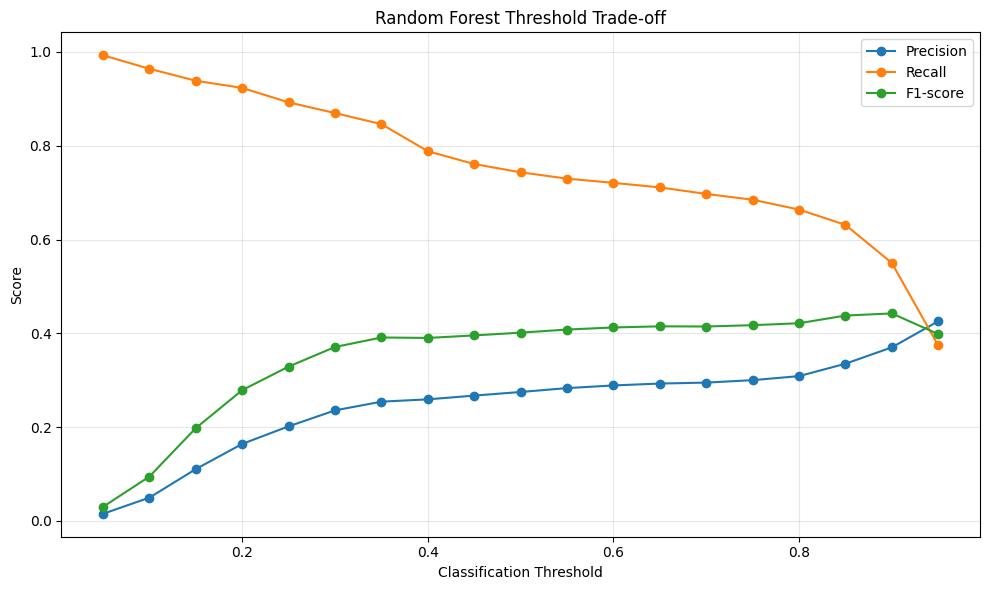

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Random Forest Business Cost Analysis

For the initial model comparison, the same business-cost assumption is applied across candidate models:

- **False Positive cost = 5**
- **False Negative cost = 100**

The 5:100 ratio represents the assumption that missing a fraudulent transaction is substantially more costly than reviewing a legitimate transaction.

These values are analytical assumptions for model comparison, not claimed real-world company costs.

In [34]:
random_forest_business_threshold_results = (
    analyze_business_thresholds(
        model=random_forest_model,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

display(random_forest_business_threshold_results)

,threshold,false_positives,false_negatives,total_cost
0,0.30,7523,348,72415.0
1,0.35,6617,411,74185.0
2,0.25,9422,287,75810.0
3,0.20,12531,205,83155.0
4,0.40,6010,565,86550.0
5,0.45,5567,638,91635.0
6,0.50,5230,685,94650.0
7,0.55,4929,721,96745.0
8,0.60,4734,745,98170.0
9,0.65,4580,771,100000.0


### Random Forest Business-Cost Comparison

The validation results identify the lowest-cost operating point under the current 5:100 cost assumption.

This threshold is retained as an analytical candidate for later model comparison. It does not determine the final production threshold.

In [35]:
random_forest_best_business_result = (
    random_forest_business_threshold_results.iloc[0]
)

random_forest_default_business_result = (
    random_forest_business_threshold_results[
        random_forest_business_threshold_results["threshold"] == 0.50
    ].iloc[0]
)

random_forest_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": random_forest_default_business_result["threshold"],
            "false_positives": random_forest_default_business_result[
                "false_positives"
            ],
            "false_negatives": random_forest_default_business_result[
                "false_negatives"
            ],
            "total_cost": random_forest_default_business_result[
                "total_cost"
            ],
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": random_forest_best_business_result["threshold"],
            "false_positives": random_forest_best_business_result[
                "false_positives"
            ],
            "false_negatives": random_forest_best_business_result[
                "false_negatives"
            ],
            "total_cost": random_forest_best_business_result[
                "total_cost"
            ],
        },
    ]
)

display(random_forest_business_comparison)

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.5,5230.0,685.0,94650.0
1,Lowest Validation Cost,0.3,7523.0,348.0,72415.0


## Feature Importance

Random Forest provides feature importance scores based on the contribution of each feature to the fitted tree ensemble.

These values are used for model interpretation and to understand which engineered signals are most useful to the model.

Feature importance is treated as an interpretation tool rather than evidence of causality.

In [36]:
random_forest_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": random_forest_model.feature_importances_,
    }
)

random_forest_feature_importance = (
    random_forest_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

random_forest_feature_importance

,feature,importance
0,terminal_fraud_rate,0.318038
1,terminal_fraud_count,0.224559
2,customer_amount_ratio,0.175353
3,customer_amount_deviation,0.093730
4,TX_AMOUNT,0.060262
5,customer_max_amount,0.031255
6,customer_amount_std,0.023760
7,customer_avg_amount,0.013379
8,terminal_max_amount,0.012465
9,customer_amount_sum_24h,0.009184


## Random Forest Feature Importance

The top features are visualized to make the model interpretation easier.

The analysis is based only on the engineered model features defined during the feature engineering stage.

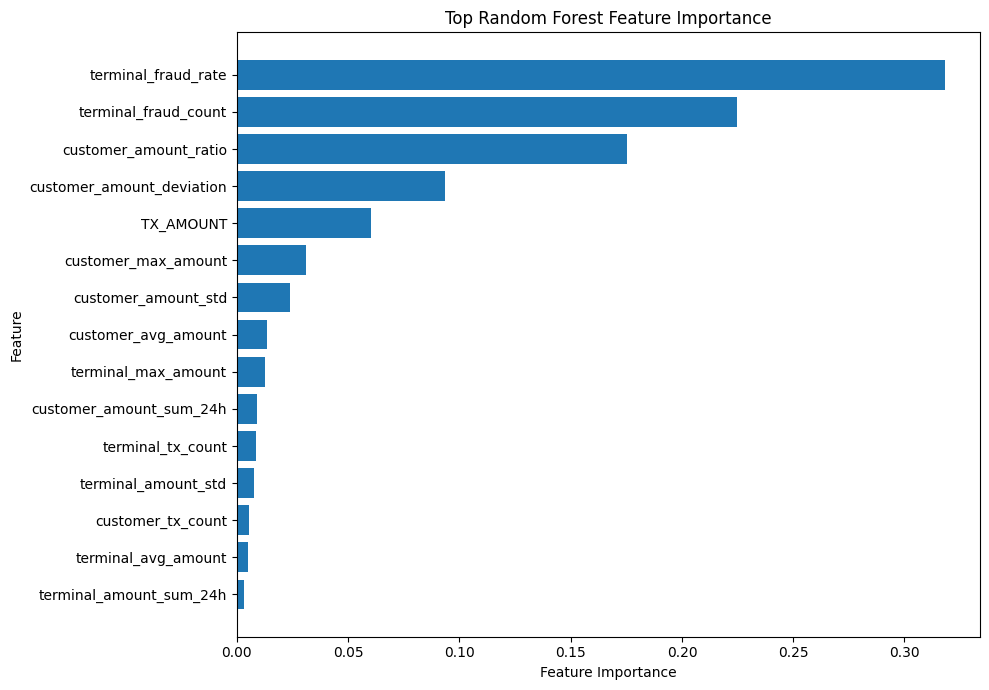

In [37]:
random_forest_top_features = (
    random_forest_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    random_forest_top_features["feature"],
    random_forest_top_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 7. Baseline Model Comparison

Logistic Regression and Random Forest are compared on the same validation set at the common 0.50 threshold.

The comparison focuses on ranking quality, fraud-class performance, and error volume to determine whether the additional complexity of a tree-based model provides meaningful improvement.

In [38]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": baseline_metrics["accuracy"],
            "precision": baseline_metrics["precision"],
            "recall": baseline_metrics["recall"],
            "f1_score": baseline_metrics["f1_score"],
            "roc_auc": baseline_metrics["roc_auc"],
            "pr_auc": baseline_metrics["pr_auc"],
            "false_positives": baseline_metrics[
                "false_positives"
            ],
            "false_negatives": baseline_metrics[
                "false_negatives"
            ],
        },
        {
            "model": "Random Forest",
            "accuracy": random_forest_metrics["accuracy"],
            "precision": random_forest_metrics["precision"],
            "recall": random_forest_metrics["recall"],
            "f1_score": random_forest_metrics["f1_score"],
            "roc_auc": random_forest_metrics["roc_auc"],
            "pr_auc": random_forest_metrics["pr_auc"],
            "false_positives": random_forest_metrics[
                "false_positives"
            ],
            "false_negatives": random_forest_metrics[
                "false_negatives"
            ],
        },
    ]
)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,false_positives,false_negatives
0,Logistic Regression,0.925162,0.093686,0.843387,0.168639,0.931600,0.177729,21776,418
1,Random Forest,0.980055,0.275021,0.743350,0.401498,0.973116,0.441577,5230,685


### Random Forest Evaluation Checks

The Random Forest section is checked for the required validation-stage outputs:

- trained model;
- validation probabilities;
- default-threshold metrics;
- threshold analysis;
- business-cost analysis;
- feature importance; and
- comparison with the Logistic Regression baseline.

The test set remains unused for model selection and threshold analysis.

In [39]:
random_forest_checks = pd.DataFrame(
    {
        "check": [
            "model_trained",
            "validation_probabilities_available",
            "default_metrics_available",
            "threshold_analysis_completed",
            "default_threshold_included",
            "business_cost_analysis_completed",
            "best_business_threshold_available",
            "feature_importance_available",
            "logistic_comparison_available",
        ],
        "result": [
            hasattr(random_forest_model, "predict_proba"),
            len(random_forest_validation_probabilities)
            == len(y_validation),
            len(random_forest_metrics) > 0,
            len(random_forest_threshold_results) > 0,
            0.50 in random_forest_threshold_results[
                "threshold"
            ].values,
            len(random_forest_business_threshold_results) > 0,
            len(random_forest_business_comparison) == 2,
            len(random_forest_feature_importance)
            == len(MODEL_FEATURES),
            len(model_comparison) == 2,
        ],
    }
)

random_forest_checks

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,best_business_threshold_available,True
7,feature_importance_available,True
8,logistic_comparison_available,True


## 8. XGBoost Baseline

XGBoost is evaluated as a stronger boosting-based candidate alongside Logistic Regression and Random Forest.

The model uses the same training and validation datasets and the same configured feature set, keeping the model comparison consistent.

Its validation workflow includes default-threshold evaluation, threshold analysis, business-cost analysis, and feature-importance review.

In [40]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

In [41]:
xgboost_model.fit(
    X_train,
    y_train,
)

print("XGBoost trained.")

XGBoost trained.


In [42]:
xgboost_validation_probabilities = (
    xgboost_model.predict_proba(X_validation)[:, 1]
)

xgboost_validation_predictions = (
    xgboost_validation_probabilities >= 0.50
).astype(int)

print("XGBoost validation predictions generated.")

XGBoost validation predictions generated.


### Standard Validation Evaluation

XGBoost is first evaluated on the validation set at the common 0.50 threshold.

The standardized evaluation provides the ranking metrics, fraud-class metrics, and confusion-matrix counts used for model comparison.

In [43]:
xgboost_metrics = evaluate_model(
    model=xgboost_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

xgboost_metrics_df = pd.DataFrame(
    {
        "metric": xgboost_metrics.keys(),
        "value": xgboost_metrics.values(),
    }
)

xgboost_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.992899
2,roc_auc,0.978097
3,pr_auc,0.714458
4,precision,0.588106
5,recall,0.704009
6,f1_score,0.640859
7,true_negatives,292574.000000
8,false_positives,1316.000000
9,false_negatives,790.000000


In [44]:
xgboost_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

xgboost_summary = (
    xgboost_metrics_df[
        xgboost_metrics_df["metric"].isin(
            xgboost_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

xgboost_summary

,metric,value
0,accuracy,0.992899
1,roc_auc,0.978097
2,pr_auc,0.714458
3,precision,0.588106
4,recall,0.704009
5,f1_score,0.640859
6,true_negatives,292574.000000
7,false_positives,1316.000000
8,false_negatives,790.000000
9,true_positives,1879.000000


## Threshold Analysis

A probability threshold determines when a transaction is classified as fraudulent.

The default threshold of 0.50 is useful for comparison, but it may not provide the best balance between precision and recall for fraud detection.

The same validation threshold grid is used to examine how model performance changes as the threshold increases.

This analysis is performed only on the validation set. The test set remains untouched for final evaluation.


In [45]:
xgboost_threshold_results = analyze_thresholds(
    model=xgboost_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

display(xgboost_threshold_results)

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.981838,0.978097,0.714458,0.313110,0.852754,0.458040,288897,4993,393,2276
1,0.10,0.986198,0.978097,0.714458,0.377453,0.821656,0.517278,290273,3617,476,2193
2,0.15,0.988319,0.978097,0.714458,0.421178,0.795804,0.550830,290971,2919,545,2124
3,0.20,0.989860,0.978097,0.714458,0.462478,0.780442,0.580789,291469,2421,586,2083
4,0.25,0.990757,0.978097,0.714458,0.491342,0.765455,0.598506,291775,2115,626,2043
5,0.30,0.991415,0.978097,0.714458,0.515757,0.754215,0.612599,292000,1890,656,2013
6,0.35,0.991907,0.978097,0.714458,0.536420,0.742226,0.622760,292178,1712,688,1981
7,0.40,0.992241,0.978097,0.714458,0.552184,0.729487,0.628571,292311,1579,722,1947
8,0.45,0.992588,0.978097,0.714458,0.570236,0.716373,0.635005,292449,1441,757,1912
9,0.50,0.992899,0.978097,0.714458,0.588106,0.704009,0.640859,292574,1316,790,1879


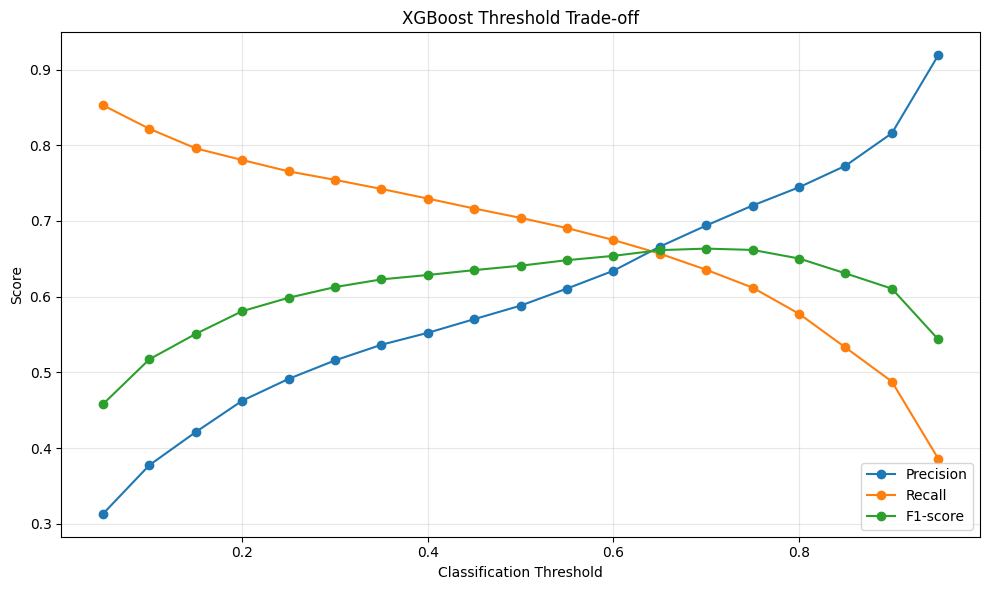

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    xgboost_threshold_results["threshold"],
    xgboost_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    xgboost_threshold_results["threshold"],
    xgboost_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    xgboost_threshold_results["threshold"],
    xgboost_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### XGBoost Business Cost Analysis

The same validation-stage cost assumption is applied to XGBoost:

- **False Positive cost = 5**
- **False Negative cost = 100**

The assumption allows business-cost operating points to be compared consistently across candidate models.

These values are analytical assumptions rather than claimed real-world costs.

In [47]:
xgboost_business_threshold_results = (
    analyze_business_thresholds(
        model=xgboost_model,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

xgboost_best_business_result = (
    xgboost_business_threshold_results.iloc[0].to_dict()
)

xgboost_default_business_result = {
    "threshold": 0.50,
    "false_positives": int(
        xgboost_metrics["false_positives"]
    ),
    "false_negatives": int(
        xgboost_metrics["false_negatives"]
    ),
    "total_cost": float(
        xgboost_metrics["false_positives"] * 5.0
        + xgboost_metrics["false_negatives"] * 100.0
    ),
}

In [48]:
xgboost_best_business_threshold = (
    xgboost_business_threshold_results.iloc[0]
)

xgboost_best_business_threshold

threshold              0.05
false_positives     4993.00
false_negatives      393.00
total_cost         64265.00
Name: 0, dtype: float64

## Feature Importance

XGBoost provides feature importance values that help identify which model features contributed most to its predictions.

This is used for model interpretation rather than as the only basis for feature selection.

The importance values are reviewed alongside model performance and the business meaning of the features.


In [49]:
xgboost_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": xgboost_model.feature_importances_,
    }
)

xgboost_feature_importance = (
    xgboost_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(xgboost_feature_importance)

,feature,importance
0,terminal_fraud_rate,0.304539
1,customer_amount_ratio,0.259980
2,terminal_fraud_count,0.071789
3,customer_tx_count,0.064818
4,TX_AMOUNT,0.039866
5,terminal_tx_count,0.038617
6,terminal_amount_std,0.038578
7,customer_max_amount,0.036729
8,customer_amount_deviation,0.036667
9,customer_avg_amount,0.018885


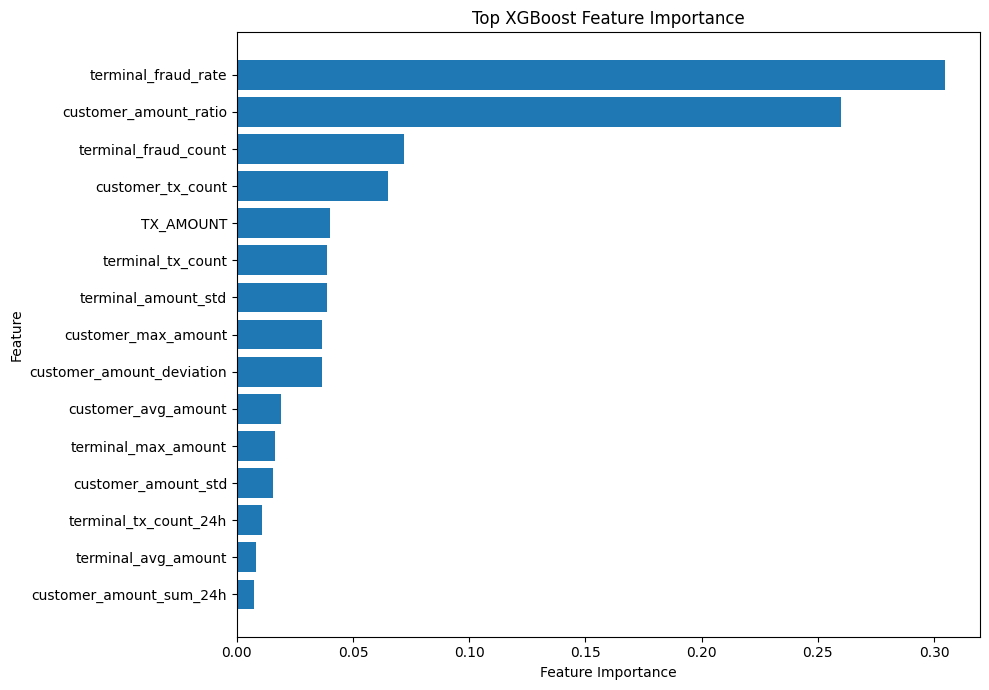

In [50]:
top_xgboost_features = (
    xgboost_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgboost_features["feature"],
    top_xgboost_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### XGBoost Evaluation Checks

The XGBoost section is checked for the required validation-stage outputs, including model training, probability generation, default-threshold evaluation, threshold analysis, business-cost analysis, and feature importance.

The test set remains untouched.

In [51]:
xgboost_checks = pd.DataFrame(
    [
        {
            "check": "model_trained",
            "result": hasattr(
                xgboost_model,
                "predict_proba",
            ),
        },
        {
            "check": "validation_probabilities_available",
            "result": len(
                xgboost_validation_probabilities
            ) == len(y_validation),
        },
        {
            "check": "default_metrics_available",
            "result": len(
                xgboost_metrics
            ) > 0,
        },
        {
            "check": "threshold_analysis_completed",
            "result": len(
                xgboost_threshold_results
            ) > 0,
        },
        {
            "check": "default_threshold_included",
            "result": (
                0.50
                in xgboost_threshold_results[
                    "threshold"
                ].values
            ),
        },
        {
            "check": "business_cost_analysis_completed",
            "result": len(
                xgboost_business_threshold_results
            ) > 0,
        },
        {
            "check": "best_business_threshold_available",
            "result": (
                not xgboost_best_business_threshold.empty
            ),
        },
        {
            "check": "feature_importance_available",
            "result": len(
                xgboost_feature_importance
            ) == len(MODEL_FEATURES),
        },
    ]
)

display(xgboost_checks)

assert xgboost_checks["result"].all(), (
    "XGBoost validation checks failed."
)

print("XGBoost validation checks passed.")

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,best_business_threshold_available,True
7,feature_importance_available,True


XGBoost validation checks passed.


## 9. HistGradientBoosting Baseline

HistGradientBoosting is evaluated as another boosting-based model for the tabular fraud-detection problem.

Boosting builds trees sequentially, allowing later trees to focus on errors from earlier trees.

The model follows the same validation workflow as the previous candidates: default-threshold evaluation, threshold analysis, business-cost analysis, and feature-importance review.

In [52]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42,
)

print(
    "HistGradientBoosting model created successfully."
)

HistGradientBoosting model created successfully.


## Model Training

The HistGradientBoosting model is trained using the same finalized training dataset used by the previous models.

The validation dataset is kept separate and is used only for model evaluation and threshold selection.


In [53]:
hist_gradient_boosting.fit(
    X_train,
    y_train,
)

print("HistGradientBoosting trained.")

HistGradientBoosting trained.


In [54]:
hist_gradient_boosting_validation_probabilities = (
    hist_gradient_boosting.predict_proba(X_validation)[:, 1]
)

hist_gradient_boosting_validation_predictions = (
    hist_gradient_boosting_validation_probabilities >= 0.50
).astype(int)

print("HistGradientBoosting validation predictions generated.")

HistGradientBoosting validation predictions generated.


## Validation Prediction Check

Before calculating evaluation metrics, I check the predicted probability distribution and the number of transactions classified as fraud at the default 0.50 threshold.

This gives a quick understanding of how aggressively the model is flagging transactions before threshold optimization.


In [55]:
hist_gradient_boosting_prediction_summary = pd.DataFrame(
    {
        "validation_records": [len(y_validation)],
        "actual_fraud_transactions": [int(y_validation.sum())],
        "predicted_fraud_transactions_at_0.50": [
            int(hist_gradient_boosting_validation_predictions.sum())
        ],
    }
)

display(hist_gradient_boosting_prediction_summary)

,validation_records,actual_fraud_transactions,predicted_fraud_transactions_at_0.50
0,296559,2669,11420


### Standard Validation Evaluation

HistGradientBoosting is evaluated on the validation set at the common 0.50 threshold.

The same evaluation metrics are used so that its performance can be compared directly with the previous candidate models.

In [56]:
hist_gradient_boosting_metrics = evaluate_model(
    model=hist_gradient_boosting,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

hist_gradient_boosting_metrics_df = pd.DataFrame(
    {
        "metric": hist_gradient_boosting_metrics.keys(),
        "value": hist_gradient_boosting_metrics.values(),
    }
)

hist_gradient_boosting_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.968428
2,roc_auc,0.975574
3,pr_auc,0.640841
4,precision,0.206918
5,recall,0.885350
6,f1_score,0.335439
7,true_negatives,284833.000000
8,false_positives,9057.000000
9,false_negatives,306.000000


In [57]:
hist_gradient_boosting_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

hist_gradient_boosting_summary = (
    hist_gradient_boosting_metrics_df[
        hist_gradient_boosting_metrics_df["metric"].isin(
            hist_gradient_boosting_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

hist_gradient_boosting_summary

,metric,value
0,accuracy,0.968428
1,roc_auc,0.975574
2,pr_auc,0.640841
3,precision,0.206918
4,recall,0.885350
5,f1_score,0.335439
6,true_negatives,284833.000000
7,false_positives,9057.000000
8,false_negatives,306.000000
9,true_positives,2363.000000


## Threshold Analysis

The model's probability output does not directly determine the final business decision.

A threshold converts the predicted fraud probability into a fraud or non-fraud decision.

Lower thresholds generally identify more fraud cases but create more false positives. Higher thresholds reduce false positives but can miss more fraudulent transactions.

Therefore, threshold analysis is performed on the validation set before making the final business decision.


In [58]:
hist_gradient_boosting_threshold_results = analyze_thresholds(
    model=hist_gradient_boosting,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

display(hist_gradient_boosting_threshold_results)

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.752784,0.975574,0.640841,0.034268,0.973773,0.066206,220646,73244,70,2599
1,0.10,0.860645,0.975574,0.640841,0.058678,0.962907,0.110616,252662,41228,99,2570
2,0.15,0.901551,0.975574,0.640841,0.080574,0.954665,0.148606,264815,29075,121,2548
3,0.20,0.924976,0.975574,0.640841,0.102388,0.944549,0.184750,271789,22101,148,2521
4,0.25,0.940150,0.975574,0.640841,0.123489,0.926564,0.217933,276337,17553,196,2473
5,0.30,0.949774,0.975574,0.640841,0.142974,0.917197,0.247385,279216,14674,221,2448
6,0.35,0.955992,0.975574,0.640841,0.159204,0.908580,0.270935,281083,12807,244,2425
7,0.40,0.960672,0.975574,0.640841,0.174461,0.902960,0.292422,282486,11404,259,2410
8,0.45,0.964884,0.975574,0.640841,0.190472,0.892844,0.313966,283762,10128,286,2383
9,0.50,0.968428,0.975574,0.640841,0.206918,0.885350,0.335439,284833,9057,306,2363


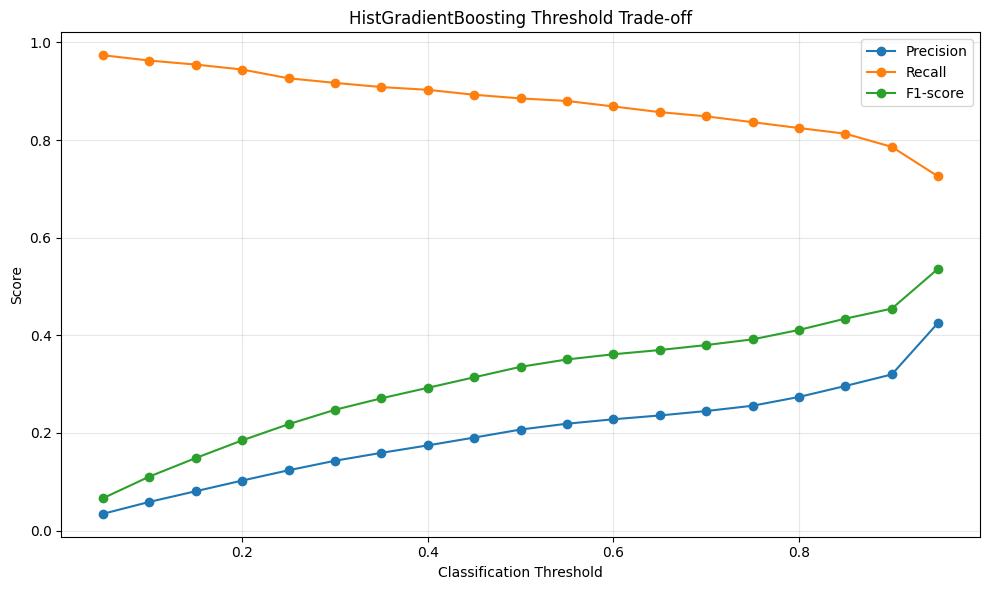

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("HistGradientBoosting Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### HistGradientBoosting Business Cost Analysis

The same validation-stage cost assumptions are applied:

- **False Positive cost = 5**
- **False Negative cost = 100**

These values are analytical assumptions used consistently to compare model operating points.

In [60]:
hist_gradient_boosting_business_threshold_results = (
    analyze_business_thresholds(
        model=hist_gradient_boosting,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

display(hist_gradient_boosting_business_threshold_results)

,threshold,false_positives,false_negatives,total_cost
0,0.55,8384,320,73920.0
1,0.60,7854,350,74270.0
2,0.65,7417,381,75185.0
3,0.70,6986,404,75330.0
4,0.85,5156,499,75680.0
5,0.50,9057,306,75885.0
6,0.80,5840,468,76000.0
7,0.75,6500,436,76100.0
8,0.45,10128,286,79240.0
9,0.90,4462,571,79410.0


In [61]:
hist_gradient_boosting_best_business_result = (
    hist_gradient_boosting_business_threshold_results
    .iloc[0]
)

hist_gradient_boosting_best_business_result

threshold              0.55
false_positives     8384.00
false_negatives      320.00
total_cost         73920.00
Name: 0, dtype: float64

### Default vs. Lowest-Cost Threshold

The default 0.50 threshold is compared with the lowest-cost operating point observed on the validation set.

This comparison illustrates the trade-off between false-positive workload and false-negative exposure under the current business-cost assumptions.

The lowest-cost validation threshold is an analytical result and is not, by itself, the production threshold.

In [62]:
hist_gradient_boosting_default_business_result = (
    hist_gradient_boosting_business_threshold_results[
        hist_gradient_boosting_business_threshold_results[
            "threshold"
        ].round(2) == 0.50
    ]
    .iloc[0]
)

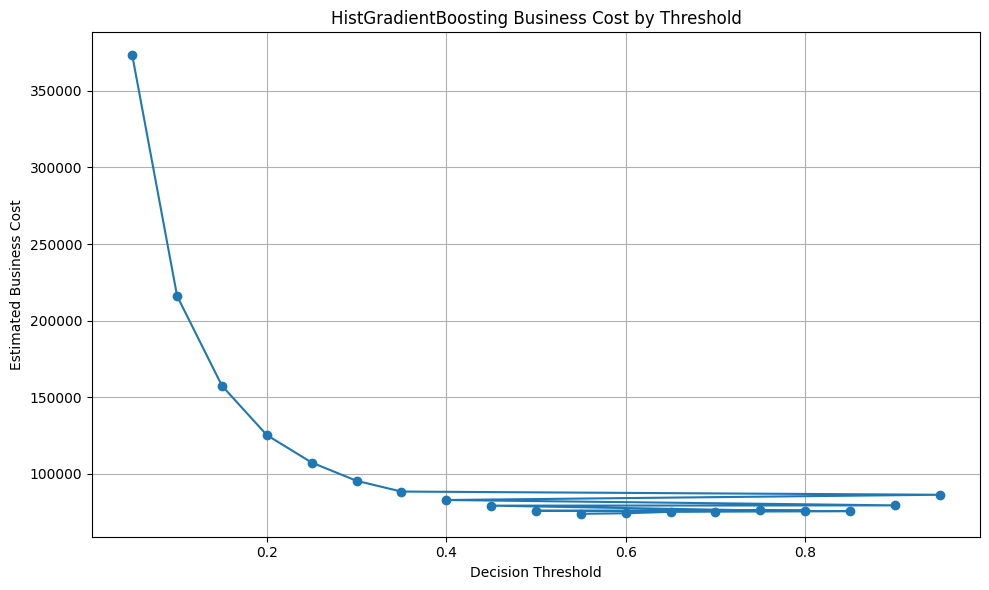

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist_gradient_boosting_business_threshold_results["threshold"],
    hist_gradient_boosting_business_threshold_results["total_cost"],
    marker="o",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Estimated Business Cost")
plt.title("HistGradientBoosting Business Cost by Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

### HistGradientBoosting Feature Importance

HistGradientBoosting does not expose the same built-in feature importance attribute used by some tree models.

Permutation importance is therefore used to estimate how much validation performance changes when each feature is shuffled.

These values describe predictive usefulness for this fitted model and validation set. They should not be interpreted as causal effects.

In [64]:
from sklearn.inspection import permutation_importance

hist_gradient_boosting_permutation = permutation_importance(
    hist_gradient_boosting,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)

In [65]:
hist_gradient_boosting_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": (
            hist_gradient_boosting_permutation.importances_mean
        ),
    }
).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

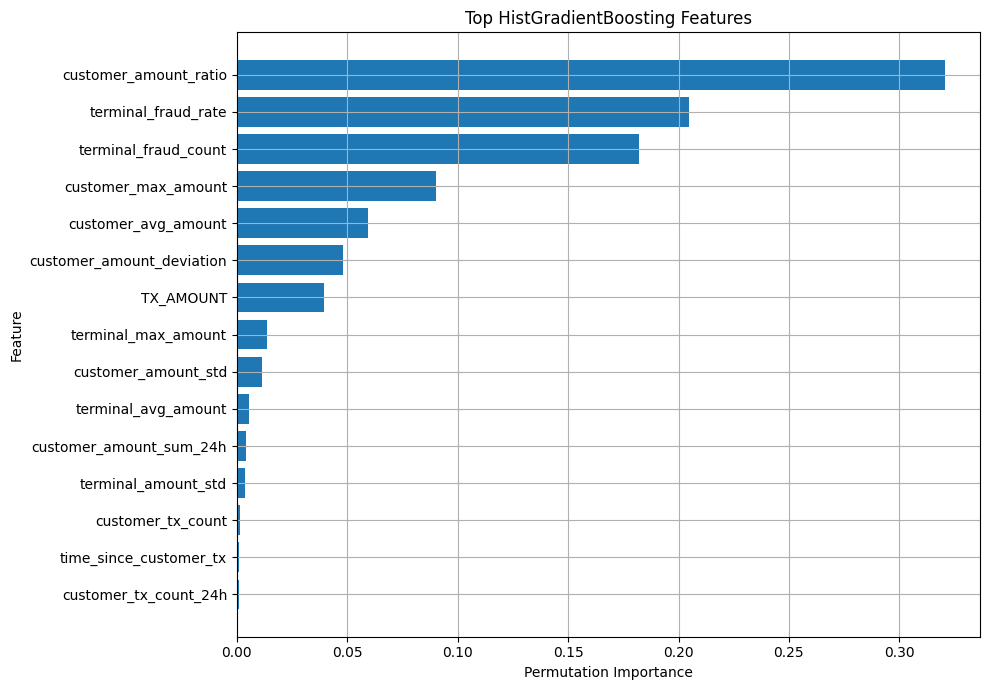

In [66]:
top_hist_gradient_boosting_features = (
    hist_gradient_boosting_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_hist_gradient_boosting_features["feature"],
    top_hist_gradient_boosting_features["importance"],
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top HistGradientBoosting Features")
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
hist_gradient_boosting_checks = pd.DataFrame(
    [
        {
            "check": "model_trained",
            "result": hasattr(
                hist_gradient_boosting,
                "predict_proba",
            ),
        },
        {
            "check": "validation_probabilities_available",
            "result": len(
                hist_gradient_boosting_validation_probabilities
            ) == len(y_validation),
        },
        {
            "check": "default_metrics_available",
            "result": len(
                hist_gradient_boosting_metrics
            ) > 0,
        },
        {
            "check": "threshold_analysis_completed",
            "result": len(
                hist_gradient_boosting_threshold_results
            ) == len(DEFAULT_THRESHOLD_GRID),
        },
        {
            "check": "default_threshold_included",
            "result": (
                0.50
                in hist_gradient_boosting_threshold_results[
                    "threshold"
                ].values
            ),
        },
        {
            "check": "business_cost_analysis_completed",
            "result": len(
                hist_gradient_boosting_business_threshold_results
            ) > 0,
        },
        {
            "check": "lowest_validation_cost_result_available",
            "result": len(
                hist_gradient_boosting_best_business_result
            ) > 0,
        },
        {
            "check": "feature_importance_available",
            "result": len(
                hist_gradient_boosting_feature_importance
            ) == len(MODEL_FEATURES),
        },
    ]
)

display(hist_gradient_boosting_checks)

assert hist_gradient_boosting_checks["result"].all(), (
    "HistGradientBoosting validation checks failed."
)

print("HistGradientBoosting validation checks passed.")

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,lowest_validation_cost_result_available,True
7,feature_importance_available,True


HistGradientBoosting validation checks passed.


# LightGBM Baseline

LightGBM is evaluated as an additional gradient-boosting candidate for the tabular fraud-detection problem.

It provides another tree-based boosting approach for comparison with XGBoost and HistGradientBoosting.

The model is evaluated using the same training and validation splits and the same evaluation framework as the previous candidates.

### Verify Gradient Boosting Dependencies

The required gradient-boosting libraries are imported to confirm that the notebook environment is ready for the candidate models.

In [68]:
import lightgbm as lgb

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.7.0


### LightGBM Classifier

LightGBM is evaluated as a tree-based gradient-boosting candidate for fraud detection.

It uses the same training features, validation set, and evaluation workflow as the previous candidate models so that performance can be compared consistently.

In [69]:
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lightgbm_model.fit(
    X_train,
    y_train,
)

[LightGBM] [Info] Number of positive: 9465, number of negative: 1160258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 1169723, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### LightGBM Validation Predictions

Validation fraud probabilities are generated from the model fitted on the training set.

A threshold of 0.50 is used for the initial candidate comparison. The probabilities are retained for subsequent threshold and business-cost analysis.

In [70]:
lightgbm_validation_probabilities = (
    lightgbm_model.predict_proba(
        X_validation,
    )[:, 1]
)

lightgbm_validation_predictions = (
    lightgbm_validation_probabilities >= 0.50
).astype(int)

print(
    "LightGBM validation probabilities generated successfully."
)

LightGBM validation probabilities generated successfully.


### LightGBM Prediction Summary

A compact validation summary checks the model output before the full evaluation.

In [71]:
lightgbm_prediction_summary = pd.DataFrame(
    {
        "validation_records": [len(y_validation)],
        "actual_fraud_transactions": [int(y_validation.sum())],
        "predicted_fraud_transactions_at_0.50": [
            int(lightgbm_validation_predictions.sum())
        ],
    }
)

display(lightgbm_prediction_summary)

,validation_records,actual_fraud_transactions,predicted_fraud_transactions_at_0.50
0,296559,2669,9987


### LightGBM Standard Evaluation

LightGBM is evaluated on the validation set at the default threshold of 0.50.

The same ranking and classification metrics used for the previous candidate models are retained for direct comparison.

In [72]:
lightgbm_metrics = evaluate_model(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)


lightgbm_metrics_df = pd.DataFrame(
    {
        "metric": lightgbm_metrics.keys(),
        "value": lightgbm_metrics.values(),
    }
)


lightgbm_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.973179
2,roc_auc,0.976631
3,pr_auc,0.646967
4,precision,0.235406
5,recall,0.880854
6,f1_score,0.371523
7,true_negatives,286254.000000
8,false_positives,7636.000000
9,false_negatives,318.000000


In [73]:
lightgbm_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]


lightgbm_summary = (
    lightgbm_metrics_df[
        lightgbm_metrics_df["metric"].isin(
            lightgbm_summary_metrics
        )
    ]
    .reset_index(drop=True)
)


lightgbm_summary

,metric,value
0,accuracy,0.973179
1,roc_auc,0.976631
2,pr_auc,0.646967
3,precision,0.235406
4,recall,0.880854
5,f1_score,0.371523
6,true_negatives,286254.000000
7,false_positives,7636.000000
8,false_negatives,318.000000
9,true_positives,2351.000000


### LightGBM Threshold Analysis

A 0.50 threshold is used for the initial comparison but is not assumed to be optimal for fraud detection.

Validation probabilities are evaluated across the standard threshold grid to examine the precision-recall and alert-volume trade-offs.

In [74]:
lightgbm_threshold_results = analyze_thresholds(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

lightgbm_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.829221,0.976631,0.646967,0.048537,0.966280,0.092431,243334,50556,90,2579
1,0.10,0.904184,0.976631,0.646967,0.082371,0.951293,0.151614,265605,28285,130,2539
2,0.15,0.932057,0.976631,0.646967,0.111659,0.941551,0.199643,273897,19993,156,2513
3,0.20,0.947275,0.976631,0.646967,0.138782,0.933308,0.241634,278432,15458,178,2491
4,0.25,0.956208,0.976631,0.646967,0.161483,0.922068,0.274834,281111,12779,208,2461
5,0.30,0.961876,0.976631,0.646967,0.180608,0.914949,0.301668,282811,11079,227,2442
6,0.35,0.965761,0.976631,0.646967,0.196053,0.904459,0.322253,283991,9899,255,2414
7,0.40,0.968728,0.976631,0.646967,0.210332,0.898464,0.340867,284887,9003,271,2398
8,0.45,0.971139,0.976631,0.646967,0.223214,0.889846,0.356901,285625,8265,294,2375
9,0.50,0.973179,0.976631,0.646967,0.235406,0.880854,0.371523,286254,7636,318,2351


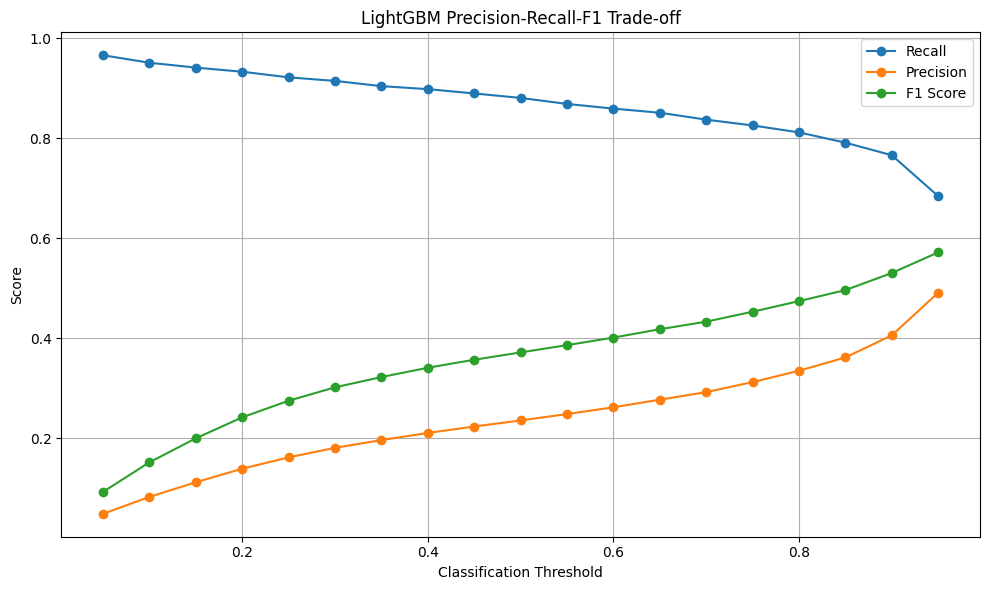

In [75]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["f1_score"],
    marker="o",
    label="F1 Score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("LightGBM Precision-Recall-F1 Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## LightGBM Business Cost Analysis

Fraud-detection errors have different operational consequences.

For this analysis:

- **False Positive = 5**
- **False Negative = 100**

The validation thresholds are evaluated under these assumptions to quantify the trade-off between investigation workload and missed-fraud exposure.

The lowest-cost validation threshold is reported as an analytical reference only.

In [76]:
lightgbm_business_threshold_results = analyze_business_thresholds(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
    false_positive_cost=5.0,
    false_negative_cost=100.0,
)

lightgbm_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.65,5931,397,69355.0
1,0.60,6473,375,69865.0
2,0.50,7636,318,69980.0
3,0.55,7024,350,70120.0
4,0.70,5417,434,70485.0
5,0.45,8265,294,70725.0
6,0.75,4857,465,70785.0
7,0.80,4304,502,71720.0
8,0.40,9003,271,72115.0
9,0.85,3730,557,74350.0


In [77]:
lightgbm_best_business_result = (
    lightgbm_business_threshold_results.iloc[0]
)


lightgbm_best_business_result

threshold              0.65
false_positives     5931.00
false_negatives      397.00
total_cost         69355.00
Name: 0, dtype: float64

In [78]:
lightgbm_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": lightgbm_metrics[
                "false_positives"
            ],
            "false_negatives": lightgbm_metrics[
                "false_negatives"
            ],
            "total_cost": (
                lightgbm_metrics["false_positives"] * 5
                + lightgbm_metrics["false_negatives"] * 100
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": lightgbm_best_business_result[
                "threshold"
            ],
            "false_positives": lightgbm_best_business_result[
                "false_positives"
            ],
            "false_negatives": lightgbm_best_business_result[
                "false_negatives"
            ],
            "total_cost": lightgbm_best_business_result[
                "total_cost"
            ],
        },
    ]
)


lightgbm_business_comparison

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.50,7636.0,318.0,69980.0
1,Lowest Validation Cost,0.65,5931.0,397.0,69355.0


## LightGBM Feature Importance

Feature importance is reviewed to understand which engineered variables contribute most to the fitted LightGBM model.

These values are model-derived predictive signals and should not be interpreted as evidence of causal relationships.

In [79]:
lightgbm_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": lightgbm_model.feature_importances_,
    }
)

lightgbm_feature_importance = (
    lightgbm_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

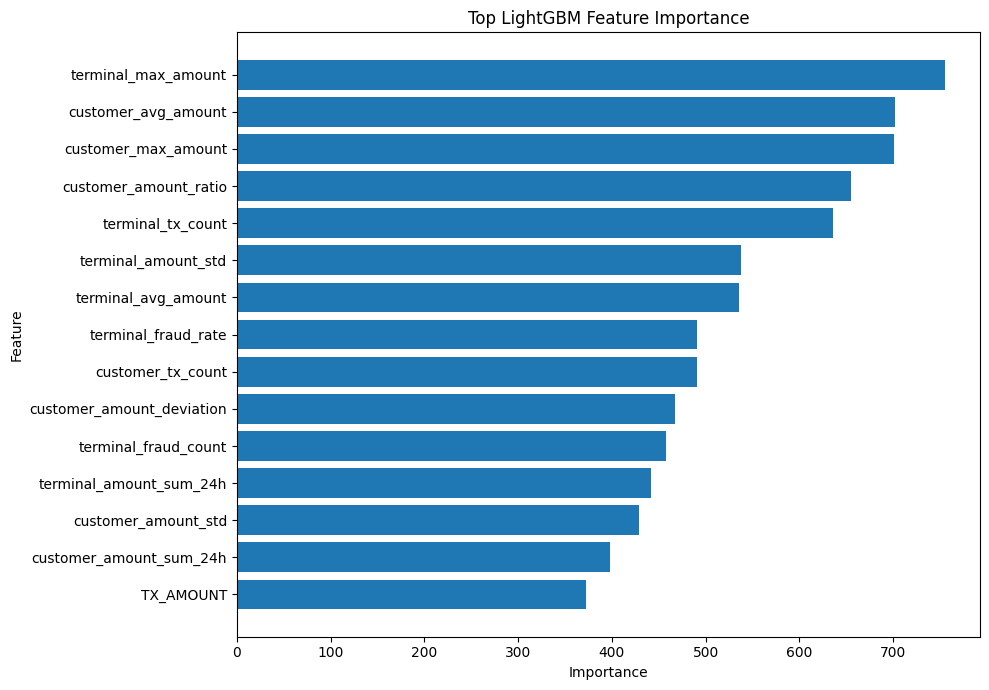

In [80]:
top_lightgbm_features = (
    lightgbm_feature_importance
    .head(15)
    .sort_values("importance")
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_lightgbm_features["feature"],
    top_lightgbm_features["importance"],
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top LightGBM Feature Importance")
plt.tight_layout()
plt.show()

# CatBoost Candidate Model

CatBoost is evaluated as an additional gradient-boosting candidate for fraud detection.

The objective is to compare its validation performance and business-cost behavior with the existing candidate models using the same evaluation framework.

The model uses the same training and validation splits as the other candidates.

In [81]:
from catboost import CatBoostClassifier

## CatBoost Model Training

CatBoost is trained as a binary classifier using the same modeling features and training split as the previous candidates.

Only the training set is used during fitting. The validation set remains separate for model evaluation, threshold analysis, business-cost analysis, and candidate comparison.

The configuration is intentionally moderate because tuning is handled separately after candidate evaluation.

In [82]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

catboost_model.fit(
    X_train,
    y_train,
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


### CatBoost Validation Predictions

Fraud probabilities are generated on the validation set for threshold and business-cost analysis.

The test set remains untouched at this stage.

In [83]:
catboost_validation_probabilities = (
    catboost_model.predict_proba(X_validation)[:, 1]
)

print(
    "CatBoost validation probabilities generated:",
    catboost_validation_probabilities.shape,
)

CatBoost validation probabilities generated: (296559,)


## CatBoost Standard Evaluation

CatBoost is first evaluated on the validation set at the default threshold of 0.50.

The same evaluation procedure used for the other candidate models is retained for direct comparison.

In [84]:
catboost_default_metrics = evaluate_model(
    model=catboost_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

pd.Series(catboost_default_metrics)

threshold               0.500000
accuracy                0.993617
roc_auc                 0.976097
pr_auc                  0.743215
precision               0.625566
recall                  0.724241
f1_score                0.671297
true_negatives     292733.000000
false_positives      1157.000000
false_negatives       736.000000
true_positives       1933.000000
dtype: float64

## CatBoost Threshold Analysis

CatBoost is evaluated across the standard probability threshold grid.

The analysis shows how precision, recall, F1-score, and classification errors change as the decision threshold moves.

Using the same threshold grid across candidate models keeps the operating-point comparison consistent.

In [85]:
catboost_threshold_results = analyze_thresholds(
    model=catboost_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

catboost_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.979289,0.976097,0.743215,0.287636,0.881229,0.433708,288065,5825,317,2352
1,0.10,0.984711,0.976097,0.743215,0.353542,0.843387,0.498229,289774,4116,418,2251
2,0.15,0.987500,0.976097,0.743215,0.403746,0.815661,0.540131,290675,3215,492,2177
3,0.20,0.989206,0.976097,0.743215,0.444653,0.800674,0.571773,291221,2669,532,2137
4,0.25,0.990447,0.976097,0.743215,0.481227,0.787561,0.597414,291624,2266,567,2102
5,0.30,0.991449,0.976097,0.743215,0.516613,0.774822,0.619904,291955,1935,601,2068
6,0.35,0.992089,0.976097,0.743215,0.543147,0.761709,0.634124,292180,1710,636,2033
7,0.40,0.992700,0.976097,0.743215,0.572165,0.748595,0.648596,292396,1494,671,1998
8,0.45,0.993216,0.976097,0.743215,0.600183,0.737355,0.661735,292579,1311,701,1968
9,0.50,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933


### CatBoost Threshold Trade-off

Changing the classification threshold changes the balance between precision and recall.

The validation curve shows how CatBoost behaves across different operating points before applying business-cost assumptions.

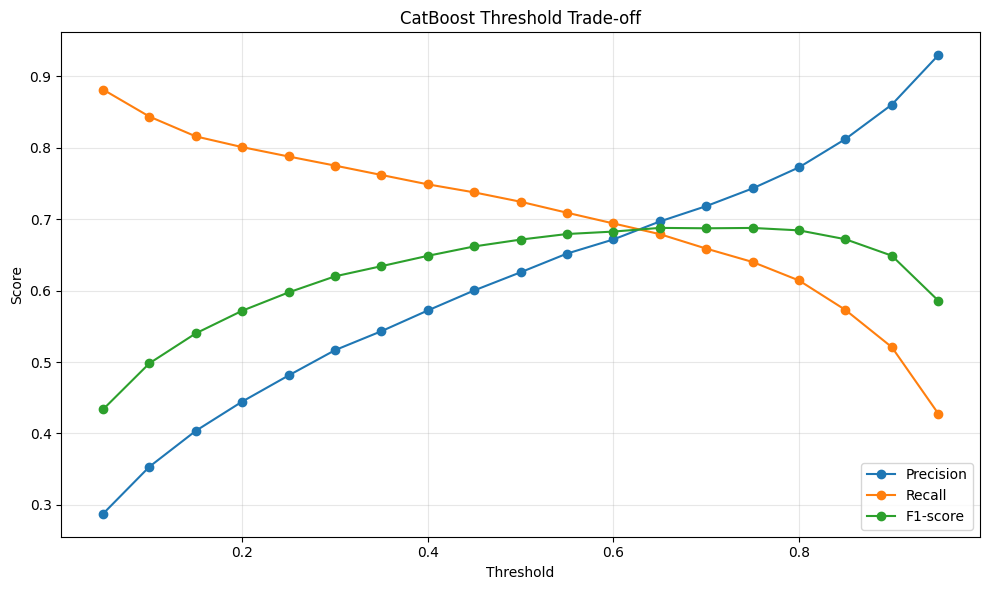

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("CatBoost Threshold Trade-off")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## CatBoost Business Cost Analysis

False positives and false negatives have different operational consequences.

For consistency with the other candidate models:

- **False Positive = 5**
- **False Negative = 100**

The validation thresholds are evaluated under these assumptions to quantify the resulting business-cost trade-off.

In [87]:
catboost_business_threshold_results = (
    analyze_business_thresholds(
        model=catboost_model,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

catboost_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.05,5825,317,60825.0
1,0.10,4116,418,62380.0
2,0.15,3215,492,65275.0
3,0.20,2669,532,66545.0
4,0.25,2266,567,68030.0
5,0.30,1935,601,69775.0
6,0.35,1710,636,72150.0
7,0.40,1494,671,74570.0
8,0.45,1311,701,76655.0
9,0.50,1157,736,79385.0


### CatBoost Lowest-Cost Validation Threshold

The validation results identify 0.05 as the lowest-cost threshold under the current business-cost assumptions.

This is an analytical validation result only.

The production threshold is selected later after predictive comparison, business robustness review, and final model selection.

In [88]:
catboost_best_business_threshold = (
    catboost_business_threshold_results
    .sort_values("total_cost")
    .iloc[0]
)

catboost_best_business_threshold

threshold              0.05
false_positives     5825.00
false_negatives      317.00
total_cost         60825.00
Name: 0, dtype: float64

## CatBoost Feature Importance

Feature importance is reviewed to identify which engineered variables contribute most to the fitted CatBoost model.

The ranking can be compared qualitatively with other tree-based models to identify recurring predictive signals.

These values describe model behavior and should not be interpreted as causal relationships.

In [89]:
catboost_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": catboost_model.feature_importances_,
    }
)

catboost_feature_importance = (
    catboost_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

catboost_feature_importance

,feature,importance
0,terminal_fraud_count,15.062867
1,customer_max_amount,14.154819
2,customer_amount_ratio,12.751988
3,terminal_fraud_rate,11.329702
4,customer_avg_amount,9.056368
5,terminal_max_amount,8.395463
6,terminal_tx_count,6.095360
7,customer_tx_count,4.064460
8,terminal_amount_std,3.964606
9,terminal_avg_amount,3.616090


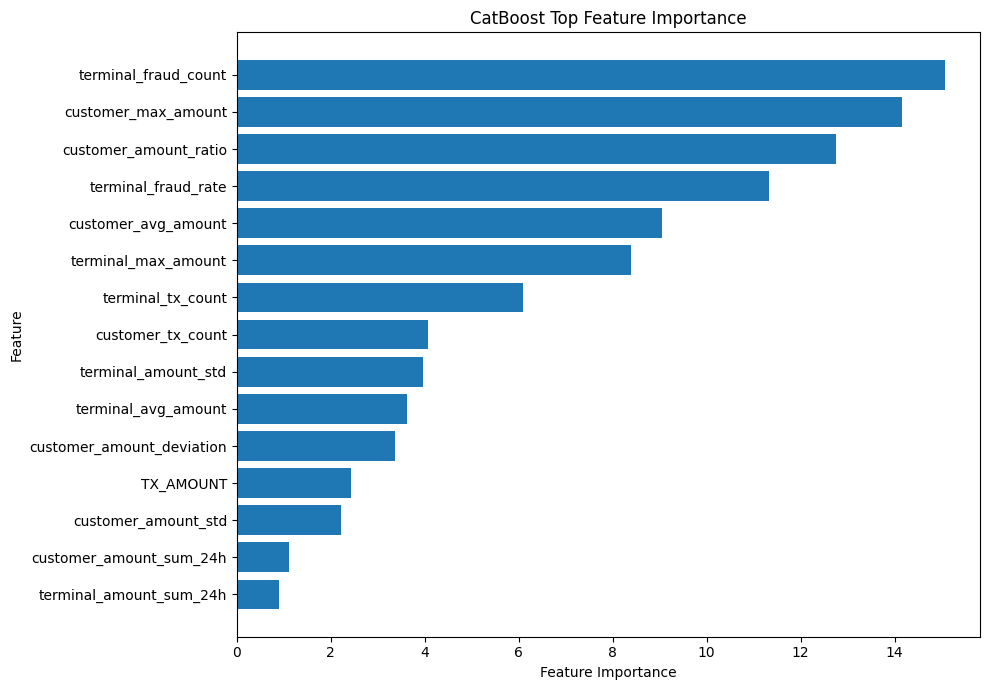

In [90]:
catboost_top_features = (
    catboost_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    catboost_top_features["feature"],
    catboost_top_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Top Feature Importance")

plt.tight_layout()
plt.show()

## Six-Model Validation Comparison

The six individual candidate models are compared on the same validation dataset at the default threshold of 0.50.

PR-AUC, precision, recall, and F1-score receive particular attention because fraud is highly imbalanced. False-positive and false-negative counts are retained to show the operational trade-offs.

This comparison establishes the individual-model benchmark before ensemble evaluation.

In [91]:
models = {
    "Logistic Regression": logistic_baseline,
    "Random Forest": random_forest_model,
    "HistGradientBoosting": hist_gradient_boosting,
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model,
    "CatBoost": catboost_model,
}

model_results = {}

for model_name, model in models.items():
    model_results[model_name] = evaluate_model(
        model=model,
        X=X_validation,
        y=y_validation,
        threshold=0.50,
    )

model_comparison = build_model_comparison(
    model_results
)

model_comparison

,model,roc_auc,pr_auc,precision,recall,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives
0,CatBoost,0.976097,0.743215,0.625566,0.724241,0.671297,0.993617,1933,1157,736,292733
1,XGBoost,0.978097,0.714458,0.588106,0.704009,0.640859,0.992899,1879,1316,790,292574
2,LightGBM,0.976631,0.646967,0.235406,0.880854,0.371523,0.973179,2351,7636,318,286254
3,HistGradientBoosting,0.975574,0.640841,0.206918,0.885350,0.335439,0.968428,2363,9057,306,284833
4,Random Forest,0.973116,0.441577,0.275021,0.743350,0.401498,0.980055,1984,5230,685,288660
5,Logistic Regression,0.931600,0.177729,0.093686,0.843387,0.168639,0.925162,2251,21776,418,272114


### Model Performance Summary

The validation results provide the primary benchmark for the six individual candidate models.

PR-AUC is emphasized for ranking performance on the minority fraud class, while precision, recall, F1-score, and error counts describe the classification trade-offs at the 0.50 threshold.

In [92]:
model_comparison_summary = model_comparison[
    [
        "accuracy",
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
        "false_positives",
        "false_negatives",
    ]
].round(4)

model_comparison_summary

,accuracy,roc_auc,pr_auc,precision,recall,f1_score,false_positives,false_negatives
0,0.9936,0.9761,0.7432,0.6256,0.7242,0.6713,1157,736
1,0.9929,0.9781,0.7145,0.5881,0.7040,0.6409,1316,790
2,0.9732,0.9766,0.6470,0.2354,0.8809,0.3715,7636,318
3,0.9684,0.9756,0.6408,0.2069,0.8854,0.3354,9057,306
4,0.9801,0.9731,0.4416,0.2750,0.7433,0.4015,5230,685
5,0.9252,0.9316,0.1777,0.0937,0.8434,0.1686,21776,418


In [93]:
model_ranking = (
    model_comparison[
        [
            "pr_auc",
            "roc_auc",
            "precision",
            "recall",
            "f1_score",
            "false_positives",
            "false_negatives",
        ]
    ]
    .sort_values(
        by=["pr_auc", "f1_score", "recall"],
        ascending=False,
    )
)

model_ranking

,pr_auc,roc_auc,precision,recall,f1_score,false_positives,false_negatives
0,0.743215,0.976097,0.625566,0.724241,0.671297,1157,736
1,0.714458,0.978097,0.588106,0.704009,0.640859,1316,790
2,0.646967,0.976631,0.235406,0.880854,0.371523,7636,318
3,0.640841,0.975574,0.206918,0.885350,0.335439,9057,306
4,0.441577,0.973116,0.275021,0.743350,0.401498,5230,685
5,0.177729,0.931600,0.093686,0.843387,0.168639,21776,418


## Validation Probability Collection

The six individual models generate fraud probabilities for the same validation records.

These probabilities are stored together so that ensemble candidates can be evaluated without retraining the individual models.

In [94]:
validation_probabilities = {
    "Logistic Regression": baseline_validation_probabilities,
    "Random Forest": random_forest_validation_probabilities,
    "HistGradientBoosting": hist_gradient_boosting_validation_probabilities,
    "XGBoost": xgboost_validation_probabilities,
    "LightGBM": lightgbm_validation_probabilities,
    "CatBoost": catboost_validation_probabilities,
}

validation_probabilities_df = pd.DataFrame(
    validation_probabilities,
    index=X_validation.index,
)

validation_probabilities_df.head()

,Logistic Regression,Random Forest,HistGradientBoosting,XGBoost,LightGBM,CatBoost
0,0.262638,0.036365,0.016152,0.000285,0.008439,0.000222
1,0.099516,0.162890,0.202722,0.001602,0.186261,0.000777
2,0.504619,0.141208,0.227597,0.004542,0.448030,0.004130
3,0.018410,0.063374,0.036423,0.000996,0.023868,0.000350
4,0.042851,0.033596,0.018995,0.000279,0.025594,0.000414


In [95]:
assert validation_probabilities_df.shape == (
    len(y_validation),
    len(models),
)

assert validation_probabilities_df.notna().all().all()

print("Validation probability integrity checks passed.")

Validation probability integrity checks passed.


## Alert Volume Comparison

The number of transactions classified as fraud at the default 0.50 threshold is compared across the six candidate models.

This provides an operational view of how aggressively each model generates alerts before threshold optimization.

In [96]:
alert_volume_comparison = pd.DataFrame(
    {
        "model": list(models.keys()),
        "fraud_predictions_at_0_50": [
            int(
                (probabilities >= 0.50).sum()
            )
            for probabilities in validation_probabilities.values()
        ],
    }
).sort_values(
    "fraud_predictions_at_0_50",
    ascending=False,
).reset_index(drop=True)

alert_volume_comparison

,model,fraud_predictions_at_0_50
0,Logistic Regression,24027
1,HistGradientBoosting,11420
2,LightGBM,9987
3,Random Forest,7214
4,XGBoost,3195
5,CatBoost,3090


### Probability Similarity Review

The mean absolute difference between CatBoost probabilities and the other candidate models is reviewed as a simple measure of prediction similarity.

Smaller differences indicate more similar probability outputs. This is only a descriptive diagnostic; probability similarity alone does not determine whether an ensemble will improve performance.

In [97]:
catboost_probabilities = validation_probabilities["CatBoost"]

for model_name, probabilities in validation_probabilities.items():
    if model_name == "CatBoost":
        continue

    print(
        model_name,
        "mean absolute difference:",
        round(
            np.mean(
                np.abs(
                    catboost_probabilities - probabilities
                )
            ),
            8,
        ),
    )

Logistic Regression mean absolute difference: 0.19636357
Random Forest mean absolute difference: 0.0756447
HistGradientBoosting mean absolute difference: 0.06507421
XGBoost mean absolute difference: 0.00333828
LightGBM mean absolute difference: 0.04648337


## Ensemble Candidates

The individual models have already generated validation fraud probabilities for the same records.

Several probability-averaging ensembles are evaluated to test whether combining complementary model outputs improves validation performance.

Each ensemble is treated as an additional candidate and evaluated using the same validation framework.

In [98]:
import numpy as np
import pandas as pd

from app.evaluation.metrics import evaluate_probabilities
from app.evaluation.thresholds import (
    DEFAULT_THRESHOLD_GRID,
    analyze_probability_thresholds,
)
from app.evaluation.business import (
    analyze_probability_business_thresholds,
)

In [99]:
# ============================================================
# FINALIST HYPERPARAMETER TUNING
# ============================================================

catboost_tuning_results = tune_catboost(
    X_train,
    y_train,
    X_validation,
    y_validation,
)

xgboost_tuning_results = tune_xgboost(
    X_train,
    y_train,
    X_validation,
    y_validation,
)

print("CatBoost tuning results:")
display(catboost_tuning_results)

print("\nXGBoost tuning results:")
display(xgboost_tuning_results)

CatBoost tuning results:


,model,iterations,depth,learning_rate,l2_leaf_reg,roc_auc,pr_auc,precision,recall,f1_score
0,catboost_baseline,500,6,0.05,3.0,0.976097,0.743215,0.625566,0.724241,0.671297
1,catboost_regularized,500,6,0.05,8.0,0.976471,0.737937,0.622193,0.716373,0.665970
2,catboost_deeper,500,7,0.05,3.0,0.976850,0.735549,0.612575,0.722743,0.663114
3,catboost_more_iterations,700,6,0.03,3.0,0.976079,0.734802,0.630355,0.711128,0.668310
4,catboost_shallower,700,5,0.03,3.0,0.975235,0.728135,0.636425,0.709629,0.671036



XGBoost tuning results:


,model,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,roc_auc,pr_auc,precision,recall,f1_score
0,xgb_deeper,300,8,0.05,0.8,0.8,0.976920,0.717486,0.629879,0.701386,0.663712
1,xgb_baseline,300,6,0.05,0.8,0.8,0.978097,0.714458,0.588106,0.704009,0.640859
2,xgb_regularized,400,5,0.03,0.8,0.8,0.978059,0.709977,0.611019,0.693893,0.649825
3,xgb_shallow,500,4,0.03,0.8,0.8,0.976095,0.692371,0.606419,0.672537,0.637769
4,xgb_conservative,600,3,0.02,0.9,0.9,0.975419,0.681083,0.621023,0.650806,0.635565


In [100]:
# ============================================================
# SELECT BEST TUNED CONFIGURATIONS
# ============================================================

best_catboost_config = (
    catboost_tuning_results
    .iloc[0]
    .drop(labels=[
        "model",
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ])
    .to_dict()
)

best_xgboost_config = (
    xgboost_tuning_results
    .iloc[0]
    .drop(labels=[
        "model",
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ])
    .to_dict()
)

print("Best CatBoost configuration:")
print(best_catboost_config)

print("\nBest XGBoost configuration:")
print(best_xgboost_config)

Best CatBoost configuration:
{'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0}

Best XGBoost configuration:
{'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [101]:
# ============================================================
# TRAIN TUNED FINALIST MODELS
# ============================================================

tuned_catboost_model = train_tuned_catboost(
    X_train,
    y_train,
    best_catboost_config,
)

tuned_xgboost_model = train_tuned_xgboost(
    X_train,
    y_train,
    best_xgboost_config,
)

print("Tuned CatBoost trained successfully.")
print("Tuned XGBoost trained successfully.")

Tuned CatBoost trained successfully.
Tuned XGBoost trained successfully.


In [102]:
# ============================================================
# EVALUATE TUNED FINALIST MODELS
# ============================================================

tuned_catboost_metrics = evaluate_model(
    tuned_catboost_model,
    X_validation,
    y_validation,
    threshold=0.5,
)

tuned_xgboost_metrics = evaluate_model(
    tuned_xgboost_model,
    X_validation,
    y_validation,
    threshold=0.5,
)

tuned_finalist_comparison = pd.DataFrame(
    [
        {
            "model": "Tuned CatBoost",
            "roc_auc": tuned_catboost_metrics["roc_auc"],
            "pr_auc": tuned_catboost_metrics["pr_auc"],
            "precision": tuned_catboost_metrics["precision"],
            "recall": tuned_catboost_metrics["recall"],
            "f1_score": tuned_catboost_metrics["f1_score"],
        },
        {
            "model": "Tuned XGBoost",
            "roc_auc": tuned_xgboost_metrics["roc_auc"],
            "pr_auc": tuned_xgboost_metrics["pr_auc"],
            "precision": tuned_xgboost_metrics["precision"],
            "recall": tuned_xgboost_metrics["recall"],
            "f1_score": tuned_xgboost_metrics["f1_score"],
        },
    ]
).sort_values(
    by="pr_auc",
    ascending=False,
).reset_index(drop=True)

display(tuned_finalist_comparison)

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Tuned CatBoost,0.976097,0.743215,0.625566,0.724241,0.671297
1,Tuned XGBoost,0.976920,0.717486,0.629879,0.701386,0.663712


## Extended Hyperparameter Search

The focused finalist tuning provides a targeted comparison of CatBoost and XGBoost configurations.

As a final controlled extension, a randomized hyperparameter search is performed for these two finalist models using cross-validation within the training data.

The existing validation set remains separate and is used for the outer comparison of the resulting models.

This experiment is intended to test whether a broader but controlled search produces a meaningful improvement over the existing finalist configurations.

In [103]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

### Search Configuration

The search space is intentionally limited to parameters that directly control model complexity, learning behaviour, regularization, and sampling.

The chronological ordering of the training data is preserved through time-aware cross-validation.

The search uses validation-independent training folds, while the existing validation set remains reserved for final model comparison.

In [104]:
# ============================================================
# RANDOMIZED SEARCH — CATBOOST
# ============================================================

time_cv = TimeSeriesSplit(n_splits=3)

catboost_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),
    param_distributions={
        "iterations": [400, 500, 600, 700, 800],
        "depth": [5, 6, 7, 8],
        "learning_rate": [0.02, 0.03, 0.05, 0.08],
        "l2_leaf_reg": [1.0, 3.0, 5.0, 8.0],
        "random_strength": [0.5, 1.0, 2.0],
        "bagging_temperature": [0.0, 0.5, 1.0],
    },
    n_iter=10,
    scoring="average_precision",
    cv=time_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

catboost_search.fit(
    X_train,
    y_train,
)

print("CatBoost randomized search completed.")

CatBoost randomized search completed.


In [105]:
# ============================================================
# RANDOMIZED SEARCH — XGBOOST
# ============================================================

xgboost_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions={
        "n_estimators": [200, 300, 400, 500, 600],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.02, 0.03, 0.05, 0.08],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0.0, 0.1, 0.3],
        "reg_alpha": [0.0, 0.01, 0.1],
        "reg_lambda": [1.0, 3.0, 5.0],
    },
    n_iter=10,
    scoring="average_precision",
    cv=time_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

xgboost_search.fit(
    X_train,
    y_train,
)

print("XGBoost randomized search completed.")

XGBoost randomized search completed.


In [106]:
# ============================================================
# RANDOMIZED SEARCH RESULTS
# ============================================================

catboost_randomized_results = (
    pd.DataFrame(catboost_search.cv_results_)
    .sort_values(
        "mean_test_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

xgboost_randomized_results = (
    pd.DataFrame(xgboost_search.cv_results_)
    .sort_values(
        "mean_test_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Best CatBoost parameters:")
print(catboost_search.best_params_)

print("\nBest CatBoost cross-validation PR-AUC:")
print(
    f"{catboost_search.best_score_:.6f}"
)

print("\nBest XGBoost parameters:")
print(xgboost_search.best_params_)

print("\nBest XGBoost cross-validation PR-AUC:")
print(
    f"{xgboost_search.best_score_:.6f}"
)

Best CatBoost parameters:
{'random_strength': 1.0, 'learning_rate': 0.08, 'l2_leaf_reg': 5.0, 'iterations': 800, 'depth': 6, 'bagging_temperature': 0.0}

Best CatBoost cross-validation PR-AUC:
0.762795

Best XGBoost parameters:
{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}

Best XGBoost cross-validation PR-AUC:
0.759930


### Validation Check of Extended Search Models

The randomized search is optimized using training-data cross-validation.

The resulting best estimators are now evaluated on the existing validation set to determine whether the broader search improves the previously selected finalist configurations.

No test-set information is used at this stage.

In [107]:
# ============================================================
# EVALUATE EXTENDED SEARCH MODELS
# ============================================================

randomized_catboost_model = catboost_search.best_estimator_
randomized_xgboost_model = xgboost_search.best_estimator_

randomized_catboost_metrics = evaluate_model(
    randomized_catboost_model,
    X_validation,
    y_validation,
    threshold=0.5,
)

randomized_xgboost_metrics = evaluate_model(
    randomized_xgboost_model,
    X_validation,
    y_validation,
    threshold=0.5,
)

randomized_search_comparison = pd.DataFrame(
    [
        {
            "model": "RandomizedSearch CatBoost",
            "roc_auc": randomized_catboost_metrics["roc_auc"],
            "pr_auc": randomized_catboost_metrics["pr_auc"],
            "precision": randomized_catboost_metrics["precision"],
            "recall": randomized_catboost_metrics["recall"],
            "f1_score": randomized_catboost_metrics["f1_score"],
        },
        {
            "model": "RandomizedSearch XGBoost",
            "roc_auc": randomized_xgboost_metrics["roc_auc"],
            "pr_auc": randomized_xgboost_metrics["pr_auc"],
            "precision": randomized_xgboost_metrics["precision"],
            "recall": randomized_xgboost_metrics["recall"],
            "f1_score": randomized_xgboost_metrics["f1_score"],
        },
    ]
).sort_values(
    "pr_auc",
    ascending=False,
).reset_index(drop=True)

randomized_search_comparison

,model,roc_auc,pr_auc,precision,recall,f1_score
0,RandomizedSearch CatBoost,0.975955,0.742501,0.615069,0.730985,0.668036
1,RandomizedSearch XGBoost,0.978172,0.730779,0.659819,0.710004,0.683992


In [108]:
# ============================================================
# TUNED MODEL VALIDATION PROBABILITIES
# ============================================================

tuned_catboost_validation_probabilities = (
    tuned_catboost_model.predict_proba(X_validation)[:, 1]
)

tuned_xgboost_validation_probabilities = (
    tuned_xgboost_model.predict_proba(X_validation)[:, 1]
)

print(
    "Tuned CatBoost probabilities:",
    tuned_catboost_validation_probabilities.shape,
)

print(
    "Tuned XGBoost probabilities:",
    tuned_xgboost_validation_probabilities.shape,
)

Tuned CatBoost probabilities: (296559,)
Tuned XGBoost probabilities: (296559,)


In [109]:
# ============================================================
# REGISTER TUNED FINALIST MODELS
# ============================================================

models.update({
    "Tuned XGBoost": tuned_xgboost_model,
    "Tuned CatBoost": tuned_catboost_model,
})
models.update({
    "RandomizedSearch XGBoost": randomized_xgboost_model,
    "RandomizedSearch CatBoost": randomized_catboost_model,
})

## Ensemble Probability Generation

Each ensemble combines validation fraud probabilities from selected individual models using equal-weight averaging.

The resulting probabilities are evaluated as additional candidates for threshold and business-cost analysis.

In [110]:
ensemble_definitions = {
    "XGBoost + CatBoost": [
        "XGBoost",
        "CatBoost",
    ],
    "XGBoost + LightGBM": [
        "XGBoost",
        "LightGBM",
    ],
    "CatBoost + LightGBM": [
        "CatBoost",
        "LightGBM",
    ],
    "XGBoost + CatBoost + LightGBM": [
        "XGBoost",
        "CatBoost",
        "LightGBM",
    ],
    "CatBoost + LightGBM + HistGradientBoosting": [
        "CatBoost",
        "LightGBM",
        "HistGradientBoosting",
    ],
}

ensemble_probabilities = {
    ensemble_name: np.mean(
        [
            validation_probabilities[model_name]
            for model_name in model_names
        ],
        axis=0,
    )
    for ensemble_name, model_names in ensemble_definitions.items()
}

for ensemble_name, probabilities in ensemble_probabilities.items():
    print(
        ensemble_name,
        probabilities.shape,
        probabilities.min(),
        probabilities.max(),
    )

XGBoost + CatBoost (296559,) 5.668240247678375e-05 0.9997845248553665
XGBoost + LightGBM (296559,) 0.00018312169574979316 0.9995760177909375
CatBoost + LightGBM (296559,) 0.00023229540965427202 0.9998986982563218
XGBoost + CatBoost + LightGBM (296559,) 0.0001719455309854077 0.9997151369195881
CatBoost + LightGBM + HistGradientBoosting (296559,) 0.0009440885893737322 0.9993897763886275


In [111]:
tuned_ensemble_probabilities = {
    "Tuned XGBoost + Tuned CatBoost": np.mean(
        [
            tuned_xgboost_validation_probabilities,
            tuned_catboost_validation_probabilities,
        ],
        axis=0,
    ),
}

## Weighted Tuned Ensemble

The existing tuned ensemble uses equal-weight probability averaging.

As a final controlled ensemble experiment, the extended-search CatBoost and XGBoost models are combined using several fixed probability weights.

The objective is to determine whether giving more weight to one finalist produces a meaningful improvement over equal-weight averaging.

Each weighting is evaluated on the validation set using the same threshold-analysis framework used for the other candidates.

In [112]:
# ============================================================
# EXTENDED SEARCH VALIDATION PROBABILITIES
# ============================================================

randomized_catboost_validation_probabilities = (
    randomized_catboost_model.predict_proba(
        X_validation
    )[:, 1]
)

randomized_xgboost_validation_probabilities = (
    randomized_xgboost_model.predict_proba(
        X_validation
    )[:, 1]
)

In [113]:
# ============================================================
# WEIGHTED ENSEMBLE EXPERIMENT
# ============================================================

weighted_ensemble_probabilities = {}
weighted_ensemble_definitions = {}

for catboost_weight in np.arange(
    0.1,
    1.0,
    0.1,
):
    xgboost_weight = 1.0 - catboost_weight

    ensemble_name = (
        "RandomizedSearch XGBoost + "
        "RandomizedSearch CatBoost "
        f"({xgboost_weight:.1f}/{catboost_weight:.1f})"
    )

    weighted_ensemble_probabilities[
        ensemble_name
    ] = (
        xgboost_weight
        * randomized_xgboost_validation_probabilities
        + catboost_weight
        * randomized_catboost_validation_probabilities
    )

    weighted_ensemble_definitions[
        ensemble_name
    ] = {
        "models": [
            "RandomizedSearch XGBoost",
            "RandomizedSearch CatBoost",
        ],
        "weights": [
            xgboost_weight,
            catboost_weight,
        ],
    }

print(
    f"Weighted ensemble configurations: "
    f"{len(weighted_ensemble_probabilities)}"
)

print(
    f"Weighted ensemble definitions: "
    f"{len(weighted_ensemble_definitions)}"
)

Weighted ensemble configurations: 9
Weighted ensemble definitions: 9


In [114]:
# ============================================================
# WEIGHTED ENSEMBLE THRESHOLD ANALYSIS
# ============================================================

weighted_ensemble_threshold_results = {}

for model_name, probabilities in (
    weighted_ensemble_probabilities.items()
):
    weighted_ensemble_threshold_results[
        model_name
    ] = analyze_probability_thresholds(
        probabilities=probabilities,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
    )

weighted_ensemble_best_results = []

for model_name, threshold_results in (
    weighted_ensemble_threshold_results.items()
):
    best_result = (
        threshold_results
        .sort_values(
            ["f1_score", "pr_auc"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    weighted_ensemble_best_results.append(
        {
            "model": model_name,
            **best_result.to_dict(),
        }
    )

weighted_ensemble_comparison = (
    pd.DataFrame(weighted_ensemble_best_results)
    .sort_values(
        ["f1_score", "pr_auc"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

weighted_ensemble_comparison

,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994807,0.977073,0.746233,0.729565,0.672162,0.699688,293225.0,665.0,875.0,1794.0
1,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994837,0.977350,0.745643,0.735124,0.666542,0.699155,293249.0,641.0,890.0,1779.0
2,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994831,0.977604,0.744582,0.736667,0.662420,0.697573,293258.0,632.0,901.0,1768.0
3,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994713,0.976766,0.746182,0.720112,0.674785,0.696712,293190.0,700.0,868.0,1801.0
4,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.75,0.994824,0.976411,0.745345,0.738035,0.658674,0.696100,293266.0,624.0,911.0,1758.0
5,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994824,0.977828,0.742996,0.738235,0.658299,0.695979,293267.0,623.0,912.0,1757.0
6,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.60,0.994547,0.978154,0.738447,0.701070,0.687149,0.694040,293108.0,782.0,835.0,1834.0
7,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.65,0.994669,0.978017,0.740996,0.718123,0.671038,0.693783,293187.0,703.0,878.0,1791.0
8,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.60,0.994531,0.978224,0.735199,0.701424,0.683027,0.692103,293114.0,776.0,846.0,1823.0


### Weighted Ensemble Result

The weighted ensemble results are compared using the same validation-stage predictive criteria as the existing candidates.

The experiment is considered successful only if a weighting provides a meaningful improvement over the existing tuned ensemble.

If no weighting materially improves validation performance, the existing configuration remains preferred.

The test set is not used to determine the ensemble weighting.

In [115]:
# ============================================================
# SELECT BEST WEIGHTED ENSEMBLE
# ============================================================

best_weighted_ensemble = (
    weighted_ensemble_comparison
    .sort_values(
        ["f1_score", "pr_auc"],
        ascending=[False, False],
    )
    .iloc[0]
)

print(
    "Best weighted ensemble:"
)
print(
    best_weighted_ensemble["model"]
)

print(
    f"Best validation threshold: "
    f"{best_weighted_ensemble['threshold']:.2f}"
)

print(
    f"Validation PR-AUC: "
    f"{best_weighted_ensemble['pr_auc']:.6f}"
)

print(
    f"Validation F1-score: "
    f"{best_weighted_ensemble['f1_score']:.6f}"
)

Best weighted ensemble:
RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)
Best validation threshold: 0.70
Validation PR-AUC: 0.746233
Validation F1-score: 0.699688


## Default Threshold Comparison

The first comparison evaluates every individual model and ensemble using the standard classification threshold of 0.50.

This provides a consistent baseline before threshold optimization.


In [116]:
# ============================================================
# ALL CANDIDATE VALIDATION PROBABILITIES
# ============================================================

all_candidate_probabilities = {
    **validation_probabilities,
    **ensemble_probabilities,
    "Tuned CatBoost": tuned_catboost_validation_probabilities,
    "Tuned XGBoost": tuned_xgboost_validation_probabilities,
    **tuned_ensemble_probabilities,
    best_weighted_ensemble["model"]: weighted_ensemble_probabilities[
        best_weighted_ensemble["model"]
    ],
}

print(
    f"Registered probabilities for "
    f"{len(all_candidate_probabilities)} candidates."
)

default_threshold_results = []

for model_name, probabilities in all_candidate_probabilities.items():
    metrics = evaluate_probabilities(
        probabilities=probabilities,
        y=y_validation,
        threshold=0.50,
    )

    default_threshold_results.append(
        {
            "model": model_name,
            **metrics,
        }
    )

default_threshold_comparison = (
    pd.DataFrame(default_threshold_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

default_threshold_comparison

Registered probabilities for 15 candidates.


,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.5,0.993630,0.977073,0.746233,0.625321,0.729112,0.673240,292724,1166,723,1946
1,Tuned CatBoost,0.5,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933
2,CatBoost,0.5,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933
3,Tuned XGBoost + Tuned CatBoost,0.5,0.993860,0.977676,0.737034,0.641239,0.721244,0.678893,292813,1077,744,1925
4,XGBoost + CatBoost,0.5,0.993485,0.977962,0.734542,0.618833,0.718996,0.665165,292708,1182,750,1919
5,CatBoost + LightGBM,0.5,0.987075,0.978243,0.732061,0.394259,0.813039,0.531017,290556,3334,499,2170
6,XGBoost + CatBoost + LightGBM,0.5,0.991341,0.978378,0.728648,0.512634,0.767703,0.614761,291942,1948,620,2049
7,CatBoost + LightGBM + HistGradientBoosting,0.5,0.979201,0.978265,0.724731,0.282373,0.850506,0.423982,288121,5769,399,2270
8,Tuned XGBoost,0.5,0.993603,0.976920,0.717486,0.629879,0.701386,0.663712,292790,1100,797,1872
9,XGBoost,0.5,0.992899,0.978097,0.714458,0.588106,0.704009,0.640859,292574,1316,790,1879


## Best Performance Threshold Comparison

The second comparison allows each candidate to use its own validation threshold.

The threshold is selected using the highest validation F1-score. This balances precision and recall and is more informative than accuracy for the imbalanced fraud classification problem.

PR-AUC and ROC-AUC remain threshold-independent metrics and are retained for overall model comparison.


In [117]:
performance_threshold_results = {}

for model_name, probabilities in all_candidate_probabilities.items():
    performance_threshold_results[model_name] = (
        analyze_probability_thresholds(
            probabilities=probabilities,
            y=y_validation,
            thresholds=DEFAULT_THRESHOLD_GRID,
        )
    )

In [118]:
best_performance_results = []

for model_name, threshold_results in performance_threshold_results.items():
    best_result = (
        threshold_results
        .sort_values(
            ["f1_score", "pr_auc"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    best_performance_results.append(
        {
            "model": model_name,
            **best_result.to_dict(),
        }
    )

best_performance_comparison = (
    pd.DataFrame(best_performance_results)
    .sort_values(
        ["f1_score", "pr_auc"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

best_performance_comparison

,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.994807,0.977073,0.746233,0.729565,0.672162,0.699688,293225.0,665.0,875.0,1794.0
1,CatBoost,0.65,0.994450,0.976097,0.743215,0.696655,0.678906,0.687666,293101.0,789.0,857.0,1812.0
2,Tuned CatBoost,0.65,0.994450,0.976097,0.743215,0.696655,0.678906,0.687666,293101.0,789.0,857.0,1812.0
3,Tuned XGBoost + Tuned CatBoost,0.60,0.994379,0.977676,0.737034,0.687781,0.687523,0.687652,293057.0,833.0,834.0,1835.0
4,XGBoost + CatBoost,0.70,0.994558,0.977962,0.734542,0.717347,0.652304,0.683281,293204.0,686.0,928.0,1741.0
5,CatBoost + LightGBM,0.85,0.994622,0.978243,0.732061,0.729487,0.639565,0.681573,293257.0,633.0,962.0,1707.0
6,XGBoost + CatBoost + LightGBM,0.75,0.994301,0.978378,0.728648,0.688632,0.669539,0.678951,293082.0,808.0,882.0,1787.0
7,CatBoost + LightGBM + HistGradientBoosting,0.90,0.994655,0.978265,0.724731,0.741533,0.623454,0.677387,293310.0,580.0,1005.0,1664.0
8,Tuned XGBoost,0.65,0.994180,0.976920,0.717486,0.687923,0.646684,0.666667,293107.0,783.0,943.0,1726.0
9,XGBoost,0.70,0.994197,0.978097,0.714458,0.693944,0.635444,0.663407,293142.0,748.0,973.0,1696.0


## Business Cost Comparison

The third comparison evaluates each candidate under the estimated business-cost assumptions.

A false positive is assigned a cost of 5, while a false negative is assigned a cost of 100.

For each candidate, the validation threshold with the lowest estimated business cost is identified for analytical comparison.

Business cost is considered alongside predictive performance and robustness rather than used as the sole model-selection criterion.

In [119]:
business_threshold_results = {}

for model_name, probabilities in all_candidate_probabilities.items():
    business_threshold_results[model_name] = (
        analyze_probability_business_thresholds(
            probabilities=probabilities,
            y=y_validation,
            thresholds=DEFAULT_THRESHOLD_GRID,
            false_positive_cost=5.0,
            false_negative_cost=100.0,
        )
    )

In [120]:
best_business_results = []

for model_name, threshold_results in business_threshold_results.items():
    best_result = (
    threshold_results
    .sort_values(
        ["total_cost", "threshold"],
        ascending=[True, True],
    )
    .iloc[0]
)

    best_business_results.append(
        {
            "model": model_name,
            **best_result.to_dict(),
        }
    )

best_business_comparison = (
    pd.DataFrame(best_business_results)
    .sort_values("total_cost")
    .reset_index(drop=True)
)

best_business_comparison

,model,threshold,false_positives,false_negatives,total_cost
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.05,5016.0,349.0,59980.0
1,Tuned XGBoost + Tuned CatBoost,0.05,5374.0,338.0,60670.0
2,CatBoost,0.05,5825.0,317.0,60825.0
3,Tuned CatBoost,0.05,5825.0,317.0,60825.0
4,XGBoost + CatBoost,0.05,5591.0,334.0,61355.0
5,Tuned XGBoost,0.05,4519.0,403.0,62895.0
6,XGBoost + CatBoost + LightGBM,0.30,4672.0,407.0,64060.0
7,XGBoost,0.05,4993.0,393.0,64265.0
8,CatBoost + LightGBM,0.40,4992.0,401.0,65060.0
9,XGBoost + LightGBM,0.40,4942.0,413.0,66010.0


## Final Candidate Comparison

The three evaluation views are now combined:

1. Default threshold performance at 0.50.
2. Best validation performance using an optimized F1 threshold.
3. Best business performance using the 5:100 false-positive/false-negative cost assumption.

The final candidate should be selected using both statistical performance and business impact rather than a single metric.


In [121]:
# ============================================================
# FINAL CANDIDATE COMPARISON
# ============================================================

default_summary = default_threshold_comparison[
    [
        "model",
        "threshold",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ]
].rename(
    columns={
        "threshold": "default_threshold",
        "pr_auc": "default_pr_auc",
        "precision": "default_precision",
        "recall": "default_recall",
        "f1_score": "default_f1_score",
    }
)

performance_summary = best_performance_comparison[
    [
        "model",
        "threshold",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ]
].rename(
    columns={
        "threshold": "best_performance_threshold",
        "pr_auc": "best_pr_auc",
        "precision": "best_precision",
        "recall": "best_recall",
        "f1_score": "best_f1_score",
    }
)

business_summary = best_business_comparison[
    [
        "model",
        "threshold",
        "false_positives",
        "false_negatives",
        "total_cost",
    ]
].rename(
    columns={
        "threshold": "business_threshold",
        "total_cost": "business_cost",
    }
)

final_candidate_comparison = (
    default_summary
    .merge(
        performance_summary,
        on="model",
        how="inner",
    )
    .merge(
        business_summary,
        on="model",
        how="inner",
    )
)

final_candidate_comparison

,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,business_threshold,false_positives,false_negatives,business_cost
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.5,0.746233,0.625321,0.729112,0.673240,0.70,0.746233,0.729565,0.672162,0.699688,0.05,5016.0,349.0,59980.0
1,Tuned CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
2,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
3,Tuned XGBoost + Tuned CatBoost,0.5,0.737034,0.641239,0.721244,0.678893,0.60,0.737034,0.687781,0.687523,0.687652,0.05,5374.0,338.0,60670.0
4,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,5591.0,334.0,61355.0
5,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,4992.0,401.0,65060.0
6,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,4672.0,407.0,64060.0
7,CatBoost + LightGBM + HistGradientBoosting,0.5,0.724731,0.282373,0.850506,0.423982,0.90,0.724731,0.741533,0.623454,0.677387,0.55,4953.0,435.0,68265.0
8,Tuned XGBoost,0.5,0.717486,0.629879,0.701386,0.663712,0.65,0.717486,0.687923,0.646684,0.666667,0.05,4519.0,403.0,62895.0
9,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,4993.0,393.0,64265.0


## Final Candidate Review

The candidate comparison is reviewed from four perspectives:

1. **Business viability** — remove candidates whose best validation business cost is materially worse than the strongest candidate.
2. **Predictive quality** — compare the remaining candidates using validation F1-score and PR-AUC, with precision and recall as supporting measures.
3. **Default-threshold behaviour** — review performance at the standard 0.50 threshold to provide operational context.
4. **Business robustness** — compare the remaining candidates across multiple false-positive cost assumptions.

The final champion is selected primarily on predictive performance, with business cost and robustness used as supporting evidence.

The test set remains untouched until the champion and production threshold are frozen.

In [122]:
# ============================================================
# BUSINESS VIABILITY REVIEW
# ============================================================

best_business_cost = (
    final_candidate_comparison["business_cost"].min()
)

BUSINESS_COST_TOLERANCE = 0.10

business_cost_limit = (
    best_business_cost
    * (1 + BUSINESS_COST_TOLERANCE)
)

business_viable_candidates = (
    final_candidate_comparison[
        final_candidate_comparison["business_cost"]
        <= business_cost_limit
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Best validation business cost: "
    f"{best_business_cost:.2f}"
)

print(
    f"Business viability limit: "
    f"{business_cost_limit:.2f}"
)

business_viable_candidates

Best validation business cost: 59980.00
Business viability limit: 65978.00


,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,business_threshold,false_positives,false_negatives,business_cost
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.5,0.746233,0.625321,0.729112,0.673240,0.70,0.746233,0.729565,0.672162,0.699688,0.05,5016.0,349.0,59980.0
1,Tuned CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
2,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
3,Tuned XGBoost + Tuned CatBoost,0.5,0.737034,0.641239,0.721244,0.678893,0.60,0.737034,0.687781,0.687523,0.687652,0.05,5374.0,338.0,60670.0
4,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,5591.0,334.0,61355.0
5,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,4992.0,401.0,65060.0
6,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,4672.0,407.0,64060.0
7,Tuned XGBoost,0.5,0.717486,0.629879,0.701386,0.663712,0.65,0.717486,0.687923,0.646684,0.666667,0.05,4519.0,403.0,62895.0
8,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,4993.0,393.0,64265.0


## Predictive Shortlist

Candidates that satisfy the business-viability requirement are ranked by validation predictive performance.

F1-score is the primary threshold-dependent criterion, with PR-AUC as the main probability-quality measure. Precision and recall provide additional context.

The strongest candidates are retained for the final robustness review rather than declaring the champion from predictive performance alone.

In [123]:
# ============================================================
# PREDICTIVE QUALITY
# ============================================================

predictive_shortlist = (
    business_viable_candidates
    .sort_values(
        [
            "best_f1_score",
            "best_pr_auc",
            "best_precision",
            "best_recall",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

predictive_shortlist[
    [
        "model",
        "best_performance_threshold",
        "best_pr_auc",
        "best_precision",
        "best_recall",
        "best_f1_score",
    ]
]

,model,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.70,0.746233,0.729565,0.672162,0.699688
1,Tuned CatBoost,0.65,0.743215,0.696655,0.678906,0.687666
2,CatBoost,0.65,0.743215,0.696655,0.678906,0.687666
3,Tuned XGBoost + Tuned CatBoost,0.60,0.737034,0.687781,0.687523,0.687652
4,XGBoost + CatBoost,0.70,0.734542,0.717347,0.652304,0.683281
5,CatBoost + LightGBM,0.85,0.732061,0.729487,0.639565,0.681573
6,XGBoost + CatBoost + LightGBM,0.75,0.728648,0.688632,0.669539,0.678951
7,Tuned XGBoost,0.65,0.717486,0.687923,0.646684,0.666667
8,XGBoost,0.70,0.714458,0.693944,0.635444,0.663407


##  Default Threshold Sanity Check

The predictive shortlist is reviewed at the default probability threshold of 0.50.

This does not replace the optimized threshold.

Instead, it checks whether the candidate's predictive advantage is reasonably
consistent with its default operating behaviour and provides operational context
for the threshold selected later.

The final operating threshold remains validation-derived and is not selected
from the test set.

In [124]:
# ============================================================
# DEFAULT THRESHOLD SANITY CHECK
# ============================================================

default_threshold_review = (
    predictive_shortlist[
        [
            "model",
            "default_threshold",
            "default_pr_auc",
            "default_precision",
            "default_recall",
            "default_f1_score",
            "best_performance_threshold",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

default_threshold_review

,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_f1_score,business_threshold,business_cost
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.5,0.746233,0.625321,0.729112,0.673240,0.70,0.699688,0.05,59980.0
1,Tuned CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.687666,0.05,60825.0
2,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.687666,0.05,60825.0
3,Tuned XGBoost + Tuned CatBoost,0.5,0.737034,0.641239,0.721244,0.678893,0.60,0.687652,0.05,60670.0
4,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.683281,0.05,61355.0
5,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.681573,0.40,65060.0
6,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.678951,0.30,64060.0
7,Tuned XGBoost,0.5,0.717486,0.629879,0.701386,0.663712,0.65,0.666667,0.05,62895.0
8,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.663407,0.05,64265.0


## Business Sensitivity Analysis

The shortlisted candidates are evaluated under multiple business-cost assumptions:

- **High fraud loss:** false positive cost = 5, false negative cost = 100
- **Balanced operations:** false positive cost = 20, false negative cost = 100
- **High customer friction:** false positive cost = 50, false negative cost = 100

For each candidate, the minimum validation cost is calculated under each scenario.

Two robustness measures are then derived:

- **Sensitivity average cost** — average optimal cost across scenarios.
- **Sensitivity worst cost** — highest optimal cost across scenarios.

These measures provide supporting evidence about how stable the candidate's business performance is when cost assumptions change.

In [125]:
# ============================================================
#  BUSINESS SENSITIVITY ANALYSIS
# ============================================================

cost_scenarios = [
    {
        "scenario": "high_fraud_loss",
        "false_positive_cost": 5.0,
        "false_negative_cost": 100.0,
    },
    {
        "scenario": "balanced_operations",
        "false_positive_cost": 20.0,
        "false_negative_cost": 100.0,
    },
    {
        "scenario": "high_customer_friction",
        "false_positive_cost": 50.0,
        "false_negative_cost": 100.0,
    },
]

sensitivity_rows = []

for model_name in predictive_shortlist["model"]:

    probabilities = all_candidate_probabilities[
        model_name
    ]

    for scenario in cost_scenarios:

        scenario_results = (
            analyze_probability_business_thresholds(
                probabilities=probabilities,
                y=y_validation,
                thresholds=DEFAULT_THRESHOLD_GRID,
                false_positive_cost=scenario[
                    "false_positive_cost"
                ],
                false_negative_cost=scenario[
                    "false_negative_cost"
                ],
            )
        )

        best_result = (
    scenario_results
    .sort_values(
        ["total_cost", "threshold"],
        ascending=[True, True],
    )
    .iloc[0]
)

        sensitivity_rows.append(
            {
                "model": model_name,
                "scenario": scenario["scenario"],
                "best_threshold": float(
                    best_result["threshold"]
                ),
                "total_cost": float(
                    best_result["total_cost"]
                ),
                "false_positives": int(
                    best_result["false_positives"]
                ),
                "false_negatives": int(
                    best_result["false_negatives"]
                ),
            }
        )

sensitivity_comparison = pd.DataFrame(
    sensitivity_rows
)

sensitivity_comparison

,model,scenario,best_threshold,total_cost,false_positives,false_negatives
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,high_fraud_loss,0.05,59980.0,5016,349
1,RandomizedSearch XGBoost + RandomizedSearch Ca...,balanced_operations,0.50,95620.0,1166,723
2,RandomizedSearch XGBoost + RandomizedSearch Ca...,high_customer_friction,0.70,120750.0,665,875
3,Tuned CatBoost,high_fraud_loss,0.05,60825.0,5825,317
4,Tuned CatBoost,balanced_operations,0.45,96320.0,1311,701
5,Tuned CatBoost,high_customer_friction,0.65,125150.0,789,857
6,CatBoost,high_fraud_loss,0.05,60825.0,5825,317
7,CatBoost,balanced_operations,0.45,96320.0,1311,701
8,CatBoost,high_customer_friction,0.65,125150.0,789,857
9,Tuned XGBoost + Tuned CatBoost,high_fraud_loss,0.05,60670.0,5374,338


## Sensitivity Summary

The scenario-level results are aggregated for each candidate.

- A lower average cost indicates stronger performance across the evaluated business assumptions.
- A lower worst-case cost indicates greater protection against an unfavourable change in business priorities.

These measures are reviewed as supporting evidence when selecting the final champion.

In [126]:
sensitivity_summary = (
    sensitivity_comparison
    .groupby("model")
    .agg(
        sensitivity_average_cost=("total_cost", "mean"),
        sensitivity_worst_cost=("total_cost", "max"),
    )
    .reset_index()
)

sensitivity_summary

,model,sensitivity_average_cost,sensitivity_worst_cost
0,CatBoost,94098.333333,125150.0
1,CatBoost + LightGBM,97436.666667,127850.0
2,RandomizedSearch XGBoost + RandomizedSearch Ca...,92116.666667,120750.0
3,Tuned CatBoost,94098.333333,125150.0
4,Tuned XGBoost,98548.333333,133450.0
5,Tuned XGBoost + Tuned CatBoost,93886.666667,125050.0
6,XGBoost,100668.333333,134700.0
7,XGBoost + CatBoost,95631.666667,126900.0
8,XGBoost + CatBoost + LightGBM,97420.000000,128600.0


## Final Champion Evidence

All evidence required for the final decision is consolidated into a single
validation-only table.

The table contains:

- Default-threshold performance
- Best predictive-threshold performance
- Best business-cost performance
- Business sensitivity
- Robustness measures

No test-set information is used.

In [127]:
# ============================================================
# FINAL CHAMPION EVIDENCE
# ============================================================

champion_evidence = (
    predictive_shortlist[
        [
            "model",
            "default_pr_auc",
            "default_precision",
            "default_recall",
            "default_f1_score",
            "best_performance_threshold",
            "best_pr_auc",
            "best_precision",
            "best_recall",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .merge(
        sensitivity_summary,
        on="model",
        how="left",
    )
    .rename(
        columns={
            "business_threshold":
                "best_business_threshold",
            "business_cost":
                "best_business_cost",
        }
    )
    .reset_index(drop=True)
)

champion_evidence

,model,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,best_business_threshold,best_business_cost,sensitivity_average_cost,sensitivity_worst_cost
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.746233,0.625321,0.729112,0.673240,0.70,0.746233,0.729565,0.672162,0.699688,0.05,59980.0,92116.666667,120750.0
1,Tuned CatBoost,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,60825.0,94098.333333,125150.0
2,CatBoost,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,60825.0,94098.333333,125150.0
3,Tuned XGBoost + Tuned CatBoost,0.737034,0.641239,0.721244,0.678893,0.60,0.737034,0.687781,0.687523,0.687652,0.05,60670.0,93886.666667,125050.0
4,XGBoost + CatBoost,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,61355.0,95631.666667,126900.0
5,CatBoost + LightGBM,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,65060.0,97436.666667,127850.0
6,XGBoost + CatBoost + LightGBM,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,64060.0,97420.000000,128600.0
7,Tuned XGBoost,0.717486,0.629879,0.701386,0.663712,0.65,0.717486,0.687923,0.646684,0.666667,0.05,62895.0,98548.333333,133450.0
8,XGBoost,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,64265.0,100668.333333,134700.0


## Final Champion Selection

The final champion is selected from the business-viable candidates using validation evidence.

Predictive performance is the primary selection basis, using best validation F1-score followed by PR-AUC, precision, and recall.

Business robustness is reviewed separately using the sensitivity average and worst-case costs. Business cost provides additional operational context but does not override clearly stronger predictive evidence.

This produces a validation-stage champion and production threshold without using the untouched test set for model selection.

In [128]:
# ============================================================
# FINAL CHAMPION SELECTION
# ============================================================

# Work only with candidates that passed the business-viability
# and predictive-shortlist stages.
champion_candidates = (
    predictive_shortlist[
        [
            "model",
            "best_performance_threshold",
            "best_pr_auc",
            "best_precision",
            "best_recall",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .merge(
        sensitivity_summary,
        on="model",
        how="left",
    )
    .copy()
)

# ============================================================
# PREDICTIVE LEADERSHIP
# ============================================================

# Predictive performance is the primary selection basis.
#
# F1-score is the primary criterion because fraud detection
# requires a balance between precision and recall.
# PR-AUC, precision, and recall provide supporting evidence.

predictive_leader = (
    champion_candidates
    .sort_values(
        [
            "best_f1_score",
            "best_pr_auc",
            "best_precision",
            "best_recall",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
    .iloc[0]
)

# ============================================================
# BUSINESS ROBUSTNESS REVIEW
# ============================================================

# Review candidates across multiple business-cost scenarios.
#
# Lower sensitivity average and worst-case costs indicate
# stronger robustness to changes in business assumptions.

robustness_leader = (
    champion_candidates
    .sort_values(
        [
            "sensitivity_average_cost",
            "sensitivity_worst_cost",
            "best_f1_score",
            "best_pr_auc",
        ],
        ascending=[
            True,
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
    .iloc[0]
)

robustness_agrees = (
    predictive_leader["model"]
    == robustness_leader["model"]
)

# ============================================================
# FINAL DECISION
# ============================================================

# Predictive quality remains the primary selection criterion.
# Business robustness is reviewed as supporting evidence.

final_champion = predictive_leader.copy()

final_champion["selection_basis"] = (
    "Predictive leadership prioritized, "
    "with business robustness reviewed as supporting evidence"
)

# ============================================================
# FINAL CHAMPION REPORT
# ============================================================

print(
    f"FINAL CHAMPION: "
    f"{final_champion['model']}"
)

print(
    f"Best predictive threshold: "
    f"{final_champion['best_performance_threshold']:.2f}"
)

print(
    f"Best business threshold: "
    f"{final_champion['business_threshold']:.2f}"
)

print(
    f"Best PR-AUC: "
    f"{final_champion['best_pr_auc']:.6f}"
)

print(
    f"Best F1: "
    f"{final_champion['best_f1_score']:.6f}"
)

print(
    f"Best business cost: "
    f"{final_champion['business_cost']:.2f}"
)

print(
    f"Sensitivity average cost: "
    f"{final_champion['sensitivity_average_cost']:.2f}"
)

print(
    f"Sensitivity worst cost: "
    f"{final_champion['sensitivity_worst_cost']:.2f}"
)

print(
    f"Robustness leader: "
    f"{robustness_leader['model']}"
)

print(
    f"Predictive and robustness leaders agree: "
    f"{robustness_agrees}"
)

print(
    f"Selection basis: "
    f"{final_champion['selection_basis']}"
)

final_champion

FINAL CHAMPION: RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)
Best predictive threshold: 0.70
Best business threshold: 0.05
Best PR-AUC: 0.746233
Best F1: 0.699688
Best business cost: 59980.00
Sensitivity average cost: 92116.67
Sensitivity worst cost: 120750.00
Robustness leader: RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)
Predictive and robustness leaders agree: True
Selection basis: Predictive leadership prioritized, with business robustness reviewed as supporting evidence


model                         RandomizedSearch XGBoost + RandomizedSearch Ca...
best_performance_threshold                                                  0.7
best_pr_auc                                                            0.746233
best_precision                                                         0.729565
best_recall                                                            0.672162
best_f1_score                                                          0.699688
business_threshold                                                         0.05
business_cost                                                           59980.0
sensitivity_average_cost                                           92116.666667
sensitivity_worst_cost                                                 120750.0
selection_basis               Predictive leadership prioritized, with busine...
Name: 0, dtype: object

In [129]:
# ============================================================
# REUSABLE PROBABILITY ENSEMBLE
# ============================================================

from app.models.ensemble import WeightedProbabilityEnsemble

print("Reusable WeightedProbabilityEnsemble loaded successfully.")

Reusable WeightedProbabilityEnsemble loaded successfully.


In [164]:
# ============================================================
# COMPLETE ENSEMBLE DEFINITIONS
# ============================================================

all_ensemble_definitions = {
    **{
        ensemble_name: {
            "models": model_names,
            "weights": [1 / len(model_names)] * len(model_names),
        }
        for ensemble_name, model_names
        in ensemble_definitions.items()
    },
    "Tuned XGBoost + Tuned CatBoost": {
        "models": [
            "Tuned XGBoost",
            "Tuned CatBoost",
        ],
        "weights": [0.5, 0.5],
    },
    **weighted_ensemble_definitions,
}

print(
    f"Registered {len(all_ensemble_definitions)} ensemble definitions."
)

Registered 15 ensemble definitions.


In [165]:
for ensemble_name, definition in all_ensemble_definitions.items():
    print(
        f"{ensemble_name}: "
        f"models={definition.get('models')}, "
        f"weights={definition.get('weights')}"
    )

XGBoost + CatBoost: models=['XGBoost', 'CatBoost'], weights=[0.5, 0.5]
XGBoost + LightGBM: models=['XGBoost', 'LightGBM'], weights=[0.5, 0.5]
CatBoost + LightGBM: models=['CatBoost', 'LightGBM'], weights=[0.5, 0.5]
XGBoost + CatBoost + LightGBM: models=['XGBoost', 'CatBoost', 'LightGBM'], weights=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
CatBoost + LightGBM + HistGradientBoosting: models=['CatBoost', 'LightGBM', 'HistGradientBoosting'], weights=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Tuned XGBoost + Tuned CatBoost: models=['Tuned XGBoost', 'Tuned CatBoost'], weights=[0.5, 0.5]
RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.9/0.1): models=['RandomizedSearch XGBoost', 'RandomizedSearch CatBoost'], weights=[np.float64(0.9), np.float64(0.1)]
RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.8/0.2): models=['RandomizedSearch XGBoost', 'RandomizedSearch CatBoost'], weights=[np.float64(0.8), np.float64(0.2)]
RandomizedSearch XGBoost + Ran

In [166]:
# ============================================================
# MATERIALIZE ENSEMBLE MODELS
# ============================================================

for ensemble_name, definition in all_ensemble_definitions.items():
    component_models = [
        models[model_name]
        for model_name in definition["models"]
    ]

    models[ensemble_name] = WeightedProbabilityEnsemble(
        models=component_models,
        weights=definition["weights"],
    )

print(
    f"Registered {len(all_ensemble_definitions)} ensemble models."
)

Registered 15 ensemble models.


### Final Holdout Evaluation

The final champion has been selected using only the training and validation data.

The independent test set is now used once for final evaluation. The threshold selected during validation is kept fixed and is not re-optimized on the test set.

Test fraud probabilities are generated from the frozen final champion selected during the validation-stage model comparison.

This provides an unbiased estimate of how the frozen production configuration performs on unseen transactions.


In [167]:
# ============================================================
# FINAL HOLDOUT EVALUATION
# ============================================================

final_model_name = final_champion["model"]

final_threshold = float(
    final_champion["best_performance_threshold"]
)

final_model = models[final_model_name]

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

final_test_results = evaluate_probabilities(
    probabilities=test_probabilities,
    y=y_test,
    threshold=final_threshold,
)

final_test_results

{'threshold': 0.7000000000000001,
 'accuracy': 0.9905270727021985,
 'roc_auc': 0.9725731010099576,
 'pr_auc': 0.5841428700204075,
 'precision': 0.47315035799522676,
 'recall': 0.6226933647428347,
 'f1_score': 0.5377182573317512,
 'true_negatives': 283560,
 'false_positives': 1766,
 'false_negatives': 961,
 'true_positives': 1586}

### Final Test Performance Summary

The test results represent the performance of the frozen champion on completely unseen data.

The selected threshold is the validation-stage threshold and is intentionally not changed during testing.

PR-AUC and ROC-AUC measure the model's ranking capability, while precision, recall, and F1-score describe performance at the selected operating threshold.

The confusion-matrix counts provide the final view of false-positive and false-negative outcomes.


In [168]:
# ============================================================
# FINAL TEST PERFORMANCE SUMMARY
# ============================================================

final_test_summary = pd.DataFrame(
    [
        {
            "model": final_model_name,
            "threshold": final_threshold,
            "roc_auc": final_test_results["roc_auc"],
            "pr_auc": final_test_results["pr_auc"],
            "precision": final_test_results["precision"],
            "recall": final_test_results["recall"],
            "f1_score": final_test_results["f1_score"],
            "true_positives": final_test_results[
                "true_positives"
            ],
            "false_positives": final_test_results[
                "false_positives"
            ],
            "false_negatives": final_test_results[
                "false_negatives"
            ],
            "true_negatives": final_test_results[
                "true_negatives"
            ],
        }
    ]
)

final_test_summary

,model,threshold,roc_auc,pr_auc,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
0,RandomizedSearch XGBoost + RandomizedSearch Ca...,0.7,0.972573,0.584143,0.47315,0.622693,0.537718,1586,1766,961,283560


In [169]:
from app.evaluation.error_analysis import (
    analyze_prediction_errors,
    summarize_prediction_outcomes,
    compare_error_groups,
    summarize_false_negatives,
    summarize_false_positives,
    get_high_confidence_errors,
)

### Final Error Analysis

The frozen final ensemble is analyzed on the untouched test set using the validation-stage production threshold of 0.70.

The finalized error-analysis functions generate prediction probabilities, class predictions, and prediction outcomes for each transaction.

The analysis focuses on true positives, false positives, false negatives, and true negatives without changing the model or threshold.

The test set is used only for final evaluation and post-selection diagnosis.


In [140]:
# ============================================================
# FINAL ERROR ANALYSIS
# ============================================================

final_model = models[final_model_name]

error_analysis = analyze_prediction_errors(
    model=final_model,
    X=X_test,
    y=y_test,
    threshold=final_threshold,
)

error_analysis.head()

,TX_AMOUNT,hour_of_day,day_of_week,is_weekend,customer_tx_count,customer_avg_amount,customer_max_amount,customer_amount_std,time_since_customer_tx,customer_amount_deviation,...,terminal_amount_std,terminal_fraud_count,terminal_fraud_rate,terminal_tx_count_1h,terminal_tx_count_24h,terminal_amount_sum_24h,actual_label,fraud_probability,predicted_label,prediction_outcome
0,49.87,0,5,1,493,34.971947,277.15,27.413439,18128.0,14.898053,...,50.070520,1.0,0.008333,0,3,1.662900e+02,0,0.003732,0,true_negative
1,15.57,0,5,1,451,24.689867,57.09,10.753917,30096.0,-9.119867,...,31.791238,0.0,0.000000,0,0,3.552714e-14,0,0.000484,0,true_negative
2,24.34,0,5,1,103,16.801456,44.74,7.870003,103010.0,7.538544,...,39.459168,1.0,0.006711,0,2,2.586800e+02,0,0.000238,0,true_negative
3,6.42,0,5,1,390,7.995590,51.70,5.161278,37084.0,-1.575590,...,39.205183,1.0,0.006536,0,1,4.810000e+00,0,0.000839,0,true_negative
4,5.94,0,5,1,306,41.386601,101.06,18.871472,14876.0,-35.446601,...,39.973231,27.0,0.144385,0,5,3.202500e+02,0,0.094475,0,true_negative


## Prediction Outcome Summary

The final test predictions are grouped into true positives, false positives, false negatives, and true negatives.

This gives a compact view of the model's correct predictions and errors before examining the individual error groups.

In [141]:
# ============================================================
# PREDICTION OUTCOME SUMMARY
# ============================================================

outcome_summary = summarize_prediction_outcomes(
    analysis=error_analysis
)

outcome_summary

,prediction_outcome,transaction_count,percentage
0,true_negative,283560,98.501770
1,false_positive,1766,0.613465
2,true_positive,1586,0.550937
3,false_negative,961,0.333828


## Error Group Comparison

The main transaction features are compared across prediction outcomes.

This helps identify behavioural differences between correctly classified transactions and model errors. The analysis is diagnostic and does not change the final model.

In [142]:
# ============================================================
# ERROR GROUP COMPARISON
# ============================================================

error_group_comparison = compare_error_groups(
    analysis=error_analysis
)

error_group_comparison

prediction_outcome,feature,false_negative,false_positive,true_negative,true_positive
0,TX_AMOUNT,70.390333,56.232616,52.919487,165.344035
1,customer_tx_count,448.072841,405.893545,431.763733,427.992434
2,customer_amount_ratio,1.202366,1.041829,0.990004,2.864868
3,customer_amount_deviation,14.027241,2.246602,-0.645191,107.911852
4,customer_tx_count_24h,2.669095,2.463760,2.576121,2.608449
5,terminal_tx_count,179.737773,138.411099,168.350677,163.988651
6,terminal_fraud_count,14.342352,19.079841,1.231602,8.531526
7,terminal_fraud_rate,0.075875,0.138995,0.007126,0.053312
8,terminal_tx_count_24h,1.034339,0.855606,1.003579,0.960908


## False Negative Analysis

False negatives are fraudulent transactions that the final model failed to identify.

Their feature and probability distributions are examined because missed fraud represents an important business risk.

In [143]:
# ============================================================
# FALSE NEGATIVE ANALYSIS
# ============================================================

false_negative_summary = summarize_false_negatives(
    analysis=error_analysis
)

false_negative_summary

,count,mean,std,min,25%,50%,75%,max
TX_AMOUNT,961.0,70.390333,73.586190,0.390000,22.630000,50.550000,88.450000,656.850000
fraud_probability,961.0,0.232317,0.238936,0.000048,0.008012,0.133415,0.444762,0.699232
customer_tx_count,961.0,448.072841,159.987561,6.000000,341.000000,487.000000,570.000000,719.000000
customer_amount_ratio,961.0,1.202366,0.884721,0.009562,0.701821,1.020301,1.486020,8.060310
customer_amount_deviation,961.0,14.027241,62.332146,-93.274309,-13.142847,0.827131,21.481956,575.358092
terminal_tx_count,961.0,179.737773,39.972854,87.000000,153.000000,175.000000,208.000000,314.000000
terminal_fraud_count,961.0,14.342352,15.844109,0.000000,2.000000,7.000000,26.000000,84.000000
terminal_fraud_rate,961.0,0.075875,0.075709,0.000000,0.009050,0.035503,0.145833,0.368421


## False Positive Analysis

False positives are legitimate transactions incorrectly classified as fraud.

Examining these cases helps understand the operational and customer-friction implications of the final model.

In [144]:
# ============================================================
# FALSE POSITIVE ANALYSIS
# ============================================================

false_positive_summary = summarize_false_positives(
    analysis=error_analysis
)

false_positive_summary

,count,mean,std,min,25%,50%,75%,max
TX_AMOUNT,1766.0,56.232616,43.422667,0.030000,22.370000,47.030000,78.437500,219.560000
fraud_probability,1766.0,0.867608,0.086002,0.700018,0.793271,0.877014,0.949307,0.993818
customer_tx_count,1766.0,405.893545,167.278022,12.000000,278.000000,414.000000,550.000000,736.000000
customer_amount_ratio,1766.0,1.041829,0.500331,0.003814,0.700920,1.001285,1.352652,2.780717
customer_amount_deviation,1766.0,2.246602,31.115535,-95.043752,-12.396374,0.037289,15.035582,139.551736
terminal_tx_count,1766.0,138.411099,24.480732,83.000000,121.250000,139.000000,150.000000,260.000000
terminal_fraud_count,1766.0,19.079841,4.616496,0.000000,16.000000,20.000000,22.000000,31.000000
terminal_fraud_rate,1766.0,0.138995,0.027817,0.000000,0.125828,0.140845,0.155039,0.201613


## High-Confidence Error Review

The most significant prediction errors are reviewed using their predicted fraud probabilities.

This provides a focused diagnostic view of cases where the final model is most confident while still being incorrect.

In [145]:
# ============================================================
# HIGH-CONFIDENCE ERROR REVIEW
# ============================================================

high_confidence_errors = get_high_confidence_errors(
    analysis=error_analysis,
    top_n=20,
)

high_confidence_errors

{'false_positives':         TX_AMOUNT  hour_of_day  day_of_week  is_weekend  customer_tx_count  \
 236693      59.73           13            1           0                308   
 41072       45.27            8            2           0                265   
 34832       48.76           13            1           0                286   
 268566      78.76           21            4           0                316   
 139078      22.77           11            5           1                147   
 166254      48.07            9            1           0                353   
 98261       11.09            8            1           0                174   
 71253       36.43           11            5           1                192   
 57272       37.97           22            3           0                152   
 28382       53.04           21            0           0                462   
 42472        0.39           11            2           0                116   
 41787      191.90           10  

### Final Model Interpretability

The final weighted ensemble is examined using model-level feature importance to identify the variables contributing most strongly to fraud detection.

The analysis provides a view of the decision drivers represented by the finalized model and connects these results with the behavioural patterns observed during error analysis.

Feature importance is interpreted as a model-level diagnostic and does not by itself establish causal relationships between individual features and fraud.


In [170]:
# ============================================================
# FINAL MODEL FEATURE IMPORTANCE
# ============================================================

FINAL_MODEL_NAME = final_champion["model"]
final_model = models[FINAL_MODEL_NAME]

print(f"Final model: {FINAL_MODEL_NAME}")
print(
    f"Production threshold: "
    f"{final_champion['best_performance_threshold']:.2f}"
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": final_model.feature_importances_,
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance

Final model: RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)
Production threshold: 0.70


,feature,importance
0,customer_amount_ratio,0.154534
1,terminal_fraud_rate,0.141163
2,terminal_fraud_count,0.124854
3,customer_max_amount,0.104045
4,terminal_max_amount,0.082499
5,customer_avg_amount,0.063850
6,terminal_tx_count,0.060992
7,terminal_amount_std,0.047277
8,terminal_avg_amount,0.040421
9,customer_amount_deviation,0.034524


### Top Feature Importance

The top contributing features are selected to provide a focused view of the main variables used by the final model.

Only the highest-ranked features are presented to keep the interpretation concise and relevant.

In [171]:
# ============================================================
# TOP FEATURE IMPORTANCE
# ============================================================

TOP_N_FEATURES = 15

top_feature_importance = (
    feature_importance
    .head(TOP_N_FEATURES)
    .copy()
)

top_feature_importance

,feature,importance
0,customer_amount_ratio,0.154534
1,terminal_fraud_rate,0.141163
2,terminal_fraud_count,0.124854
3,customer_max_amount,0.104045
4,terminal_max_amount,0.082499
5,customer_avg_amount,0.063850
6,terminal_tx_count,0.060992
7,terminal_amount_std,0.047277
8,terminal_avg_amount,0.040421
9,customer_amount_deviation,0.034524


## Feature Importance Visualization

The top feature importances are visualized to make the final model's main decision drivers easier to interpret.

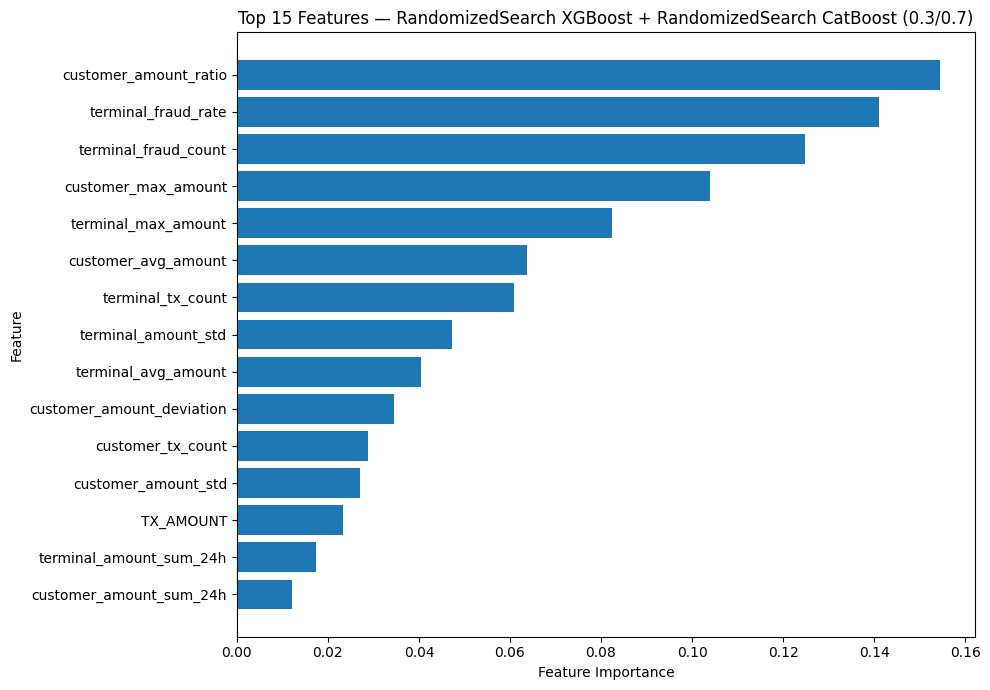

In [172]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

import matplotlib.pyplot as plt

plot_data = (
    top_feature_importance
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N_FEATURES} Features — {FINAL_MODEL_NAME}"
)

plt.tight_layout()
plt.show()

### Business Interpretation of Important Features

The final weighted ensemble relies strongly on customer-level and terminal-level behavioural features.

The strongest contributors include customer amount ratio, terminal fraud rate, terminal fraud history, customer transaction-amount patterns, and terminal transaction behaviour. These features indicate that the model uses both historical behavioural signals and transaction-level deviations when identifying potentially fraudulent activity.

The feature-importance results are interpreted together with the error analysis to understand whether the model's decision drivers are aligned with meaningful fraud patterns.

Feature importance describes the model's use of the available variables; it should not be interpreted as evidence that a feature independently causes fraud.


In [149]:
top_features = feature_importance.head(10).copy()
top_features

,feature,importance
0,customer_max_amount,8.677796
1,customer_amount_ratio,8.180983
2,terminal_max_amount,7.726837
3,terminal_fraud_rate,6.926700
4,terminal_fraud_count,6.756109
5,customer_avg_amount,5.677476
6,terminal_tx_count,4.986682
7,terminal_amount_std,3.952895
8,terminal_avg_amount,3.776083
9,customer_tx_count,2.615345


### Key Model Drivers

The most important features in the final weighted ensemble are:

* **customer_amount_ratio** — compares the current transaction amount with the customer's historical spending pattern.
* **terminal_fraud_rate** — historical fraud frequency associated with the terminal.
* **terminal_fraud_count** — historical fraud activity associated with the terminal.
* **customer_max_amount** — the customer's historical maximum transaction amount.
* **terminal_max_amount** — the maximum historical transaction amount associated with the terminal.
* **customer_avg_amount** — the customer's typical historical transaction amount.

These features indicate that the final model relies strongly on customer spending behaviour and historical terminal risk signals rather than on transaction amount alone.


## Fraud vs Legitimate Transaction Behaviour

Feature importance shows which variables are important to the model, but it does not describe the actual behaviour of fraudulent transactions.

To complement the model-level interpretation, the key features are compared between legitimate and fraudulent transactions in the test set.

In [150]:
# ============================================================
# FRAUD VS LEGITIMATE FEATURE COMPARISON
# ============================================================

comparison_features = [
    "terminal_fraud_count",
    "terminal_fraud_rate",
    "customer_max_amount",
    "customer_amount_ratio",
    "customer_avg_amount",
    "terminal_max_amount",
    "terminal_tx_count",
    "customer_tx_count",
    "customer_amount_deviation",
    "TX_AMOUNT",
]

available_features = [
    feature
    for feature in comparison_features
    if feature in X_test.columns
]

test_feature_comparison = (
    X_test.assign(actual_label=np.asarray(y_test))
    .groupby("actual_label")[available_features]
    .mean()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "feature",
            0: "legitimate_mean",
            1: "fraud_mean",
        }
    )
)

test_feature_comparison

actual_label,feature,legitimate_mean,fraud_mean
0,terminal_fraud_count,1.342072,10.723989
1,terminal_fraud_rate,0.007942,0.061825
2,customer_max_amount,157.948684,244.748771
3,customer_amount_ratio,0.990324,2.237595
4,customer_avg_amount,53.567073,57.028808
5,terminal_max_amount,232.567734,246.217185
6,terminal_tx_count,168.165369,169.930899
7,customer_tx_count,431.603611,435.568905
8,customer_amount_deviation,-0.627292,72.488565
9,TX_AMOUNT,52.939993,129.517373


### Interpretation

The comparison highlights how the most important behavioural features differ between legitimate and fraudulent transactions.

Features with large differences between the two classes provide additional evidence that the model is learning meaningful fraud-related patterns rather than relying only on the transaction amount.

This analysis is descriptive and is used to support model interpretation; it does not imply that a feature is independently causal for fraud.

### Final Model Findings

The final weighted XGBoost + CatBoost ensemble combines the predictive performance of the two randomized-search finalist models using a validation-selected probability weighting.

The final feature-importance analysis identifies customer amount ratio, terminal fraud rate, terminal fraud history, customer maximum amount, and terminal transaction behaviour among the strongest model-level signals.

The class-level comparison also shows meaningful differences in customer spending behaviour, terminal fraud history, transaction amount, and transaction-amount deviation between fraudulent and legitimate transactions.

These findings support the use of behavioural and historical transaction features as important fraud-detection signals while recognizing that feature importance and class-level differences are descriptive rather than causal.


## Business Recommendations

The model results suggest three practical actions for a fraud-monitoring system:

1. Prioritize transactions associated with terminals showing stronger historical fraud activity.
2. Monitor transactions that deviate substantially from a customer's normal spending behaviour.
3. Use the selected operating threshold to balance fraud detection against unnecessary customer friction.

The final model should therefore be treated as a decision-support component rather than an isolated prediction model.

In [151]:
# ============================================================
# FINAL BUSINESS SUMMARY
# ============================================================

business_summary = pd.DataFrame(
    {
        "finding": [
            "Terminal fraud history is a major fraud signal.",
            "Fraudulent transactions show stronger customer spending deviations.",
            "Fraudulent transactions tend to have higher transaction amounts.",
            "The operating threshold should reflect business fraud and customer-friction costs.",
        ]
    }
)

business_summary

,finding
0,Terminal fraud history is a major fraud signal.
1,Fraudulent transactions show stronger customer...
2,Fraudulent transactions tend to have higher tr...
3,The operating threshold should reflect busines...


### Conclusion

The RandomizedSearch XGBoost + RandomizedSearch CatBoost weighted ensemble was selected as the final fraud-risk model after validation-stage comparison of predictive performance, threshold behaviour, business cost, and robustness.

The selected ensemble uses a 0.3 XGBoost and 0.7 CatBoost probability weighting, with a production decision threshold of 0.70 determined during validation.

The frozen model and production threshold were then evaluated once on the untouched test set, followed by error analysis and model interpretation.

The final results show that customer and terminal behavioural history provides meaningful predictive signals for fraud detection, supporting the use of transaction-level and historical behavioural features in the production workflow.


In [152]:
from app.models.final_model import get_final_model_metadata
from app.models.model_io import save_model

artifacts_dir = PROJECT_ROOT / "artifacts"

model_metadata = get_final_model_metadata(
    model_name=FINAL_MODEL_NAME,
    model_type=final_model.__class__.__name__,
    decision_threshold=float(
        final_champion["best_performance_threshold"]
    ),
    feature_count=len(X_train.columns),
)

model_metadata.update(
    {
        "features": list(X_train.columns),
        "training_records": len(X_train),
        "test_records": len(X_test),
        "final_model": FINAL_MODEL_NAME,
        "production_threshold": float(
            final_champion["best_performance_threshold"]
        ),
    }
)

saved_artifacts = save_model(
    model=final_model,
    metadata=model_metadata,
    model_dir=artifacts_dir,
    model_filename="fraud_risk_model.joblib",
    metadata_filename="model_metadata.json",
)

print(
    f"Final {FINAL_MODEL_NAME} production artifacts "
    "saved successfully."
)
print(f"Model: {saved_artifacts['model_path']}")
print(f"Metadata: {saved_artifacts['metadata_path']}")

Final RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7) production artifacts saved successfully.
Model: C:\AI\fraud-risk-intelligence-platform\artifacts\fraud_risk_model.joblib
Metadata: C:\AI\fraud-risk-intelligence-platform\artifacts\model_metadata.json


### Portfolio Analysis

The final weighted XGBoost + CatBoost ensemble has been selected, evaluated on the untouched test set using the frozen production threshold, and saved as the production model.

The remaining analysis focuses on the key results that communicate model quality, decision-threshold behaviour, business cost, interpretability, and final test performance.


In [173]:
plots_dir = PROJECT_ROOT / "assets" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Plots directory: {plots_dir}")

Plots directory: C:\AI\fraud-risk-intelligence-platform\assets\plots


## Portfolio Visualizations

The final results are presented through a focused set of portfolio-ready visuals covering:

- validation model comparison
- threshold trade-offs
- business cost
- final test confusion matrix
- precision-recall performance
- feature importance

All visuals are generated from the finalized evaluation outputs.

### Final Champion Business Cost Analysis

False positives and false negatives have different operational costs in fraud detection.

Using the agreed validation-stage cost assumptions:

- False positive cost: 5
- False negative cost: 100

the final champion is evaluated across the validation threshold grid.

The visualization shows the lowest validation business-cost operating point separately from the frozen production threshold. The production threshold remains the model-selection decision rather than simply choosing the threshold with the lowest validation cost.

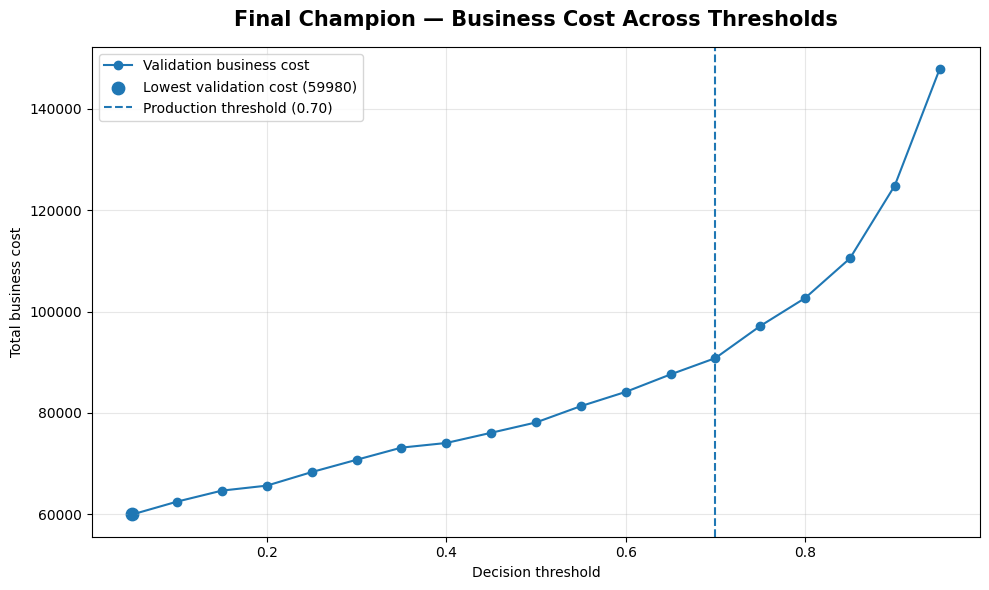

In [174]:
# ============================================================
# FINAL BUSINESS COST ANALYSIS
# ============================================================

final_business_threshold_results = (
    analyze_business_thresholds(
        model=final_model,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

best_business_row = final_business_threshold_results.loc[
    final_business_threshold_results["total_cost"].idxmin()
]

plt.figure(figsize=(10, 6))

plt.plot(
    final_business_threshold_results["threshold"],
    final_business_threshold_results["total_cost"],
    marker="o",
    label="Validation business cost",
)

plt.scatter(
    best_business_row["threshold"],
    best_business_row["total_cost"],
    s=80,
    label=(
        f"Lowest validation cost "
        f"({best_business_row['total_cost']:.0f})"
    ),
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label=(
        f"Production threshold "
        f"({final_threshold:.2f})"
    ),
)

plt.xlabel("Decision threshold")
plt.ylabel("Total business cost")
plt.title(
    "Final Champion — Business Cost Across Thresholds",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    plots_dir / "business_cost_analysis.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The lowest validation business cost and the final production threshold are shown separately.

The production threshold remains the model-selection decision rather than simply choosing the threshold with the lowest validation cost.

### Final Champion Test Confusion Matrix

The frozen final champion is evaluated once on the untouched test set using the production threshold selected during validation.

The confusion matrix shows the resulting true positives, false positives, true negatives, and false negatives at that frozen operating point.

No test-set information was used to select the model or threshold.

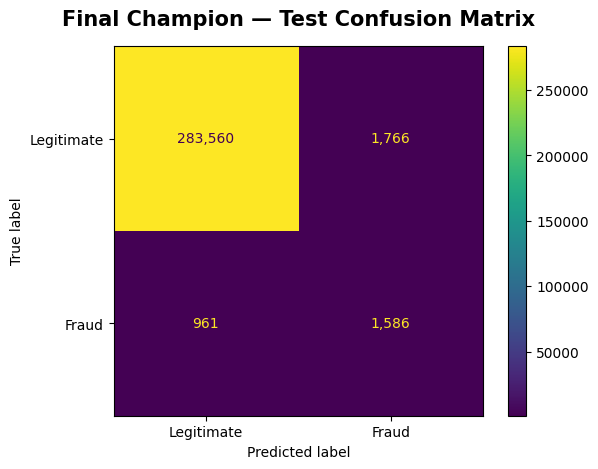

In [155]:
# ============================================================
# FINAL CHAMPION TEST CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_predictions = error_analysis["predicted_label"].to_numpy()

confusion_matrix_values = confusion_matrix(
    y_test,
    test_predictions,
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Legitimate", "Fraud"],
).plot(
    values_format=",d",
)

plt.title(
    "Final Champion — Test Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.savefig(
    plots_dir / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final Champion Feature Importance

Feature importance is used to understand which engineered signals contribute most strongly to the final champion's predictions.

For the final champion, feature importance reflects the model-derived importance aggregated across its component models.

These values support model interpretation but should not be treated as evidence of causal relationships.

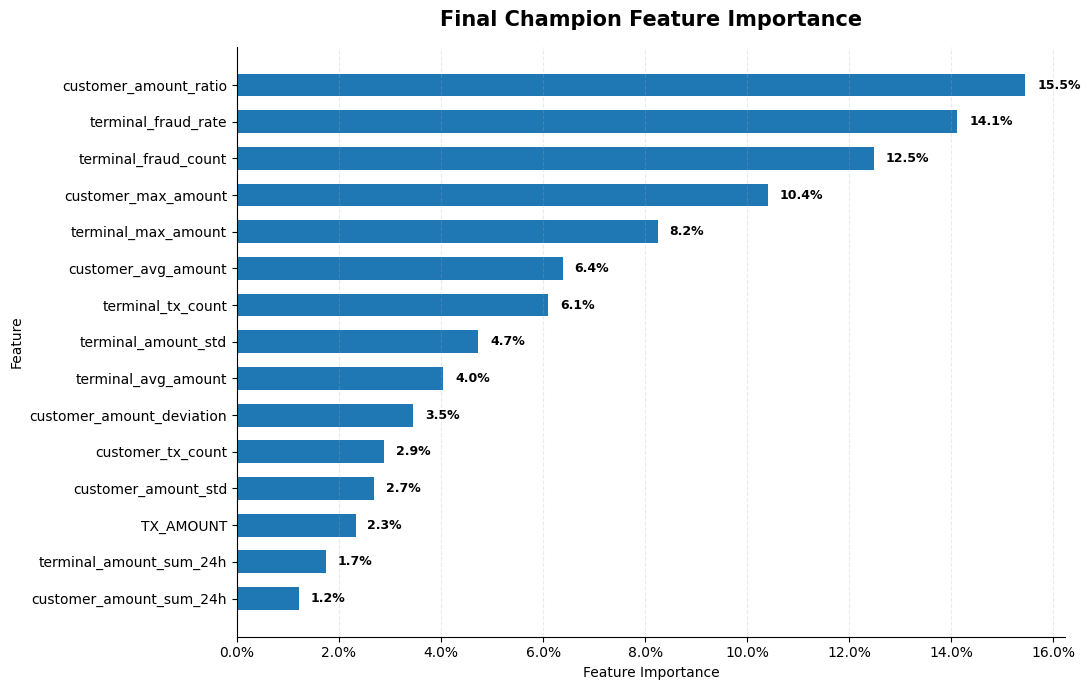

In [175]:
# ============================================================
# FINAL CHAMPION FEATURE IMPORTANCE
# ============================================================

from matplotlib.ticker import PercentFormatter

final_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": final_model.feature_importances_,
    }
).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

final_top_features = (
    final_feature_importance
    .head(15)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    final_top_features["feature"],
    final_top_features["importance"],
    height=0.62,
)

max_importance = final_top_features["importance"].max()

for bar, value in zip(
    bars,
    final_top_features["importance"],
):
    plt.text(
        value + max_importance * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1%}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Final Champion Feature Importance",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "final_champion_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final Champion Precision-Recall Curve

The precision-recall curve shows the trade-off between precision and recall for the final champion on the untouched test set.

Because fraud is a highly imbalanced classification problem, precision-recall performance provides a more informative view of minority-class detection than accuracy alone.

The reported PR-AUC summarizes the model's precision-recall performance across decision thresholds.

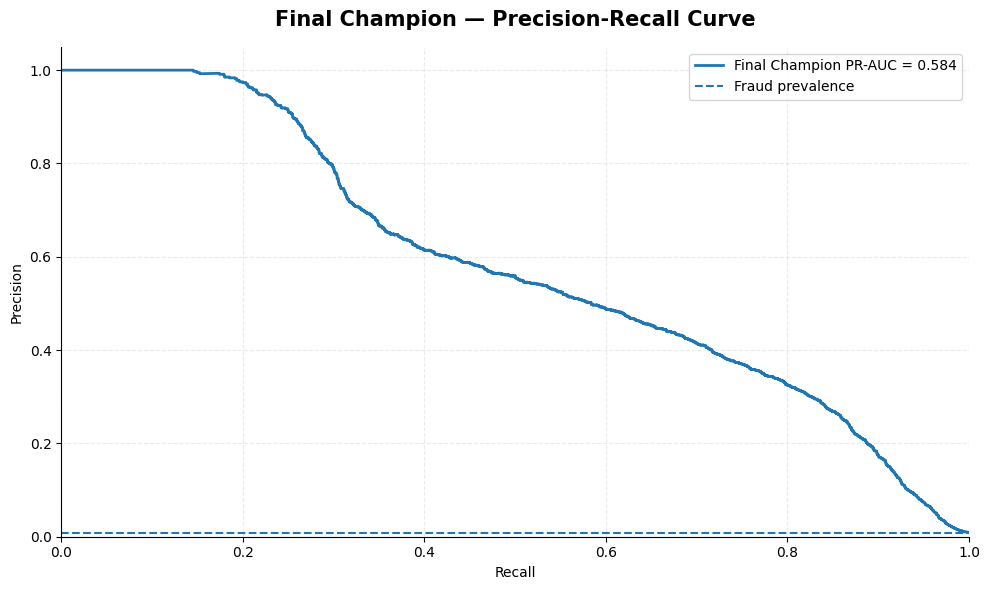

In [157]:
# ============================================================
# FINAL CHAMPION PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import precision_recall_curve

test_probabilities = error_analysis["fraud_probability"].to_numpy()

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    test_probabilities,
)

fraud_rate = y_test.mean()

plt.figure(figsize=(10, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=(
        f"Final Champion PR-AUC = "
        f"{final_test_results['pr_auc']:.3f}"
    ),
)

plt.axhline(
    fraud_rate,
    linestyle="--",
    label="Fraud prevalence",
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Final Champion — Precision-Recall Curve",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(
    linestyle="--",
    alpha=0.25,
)

plt.legend()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final Champion Threshold Trade-off

Threshold selection illustrates how precision, recall, and F1-score change as the decision threshold varies for the final champion.

The curve is evaluated on the validation set, where the production threshold was selected.

The frozen production threshold is shown separately so that the final operating point can be compared with the broader precision-recall trade-off.

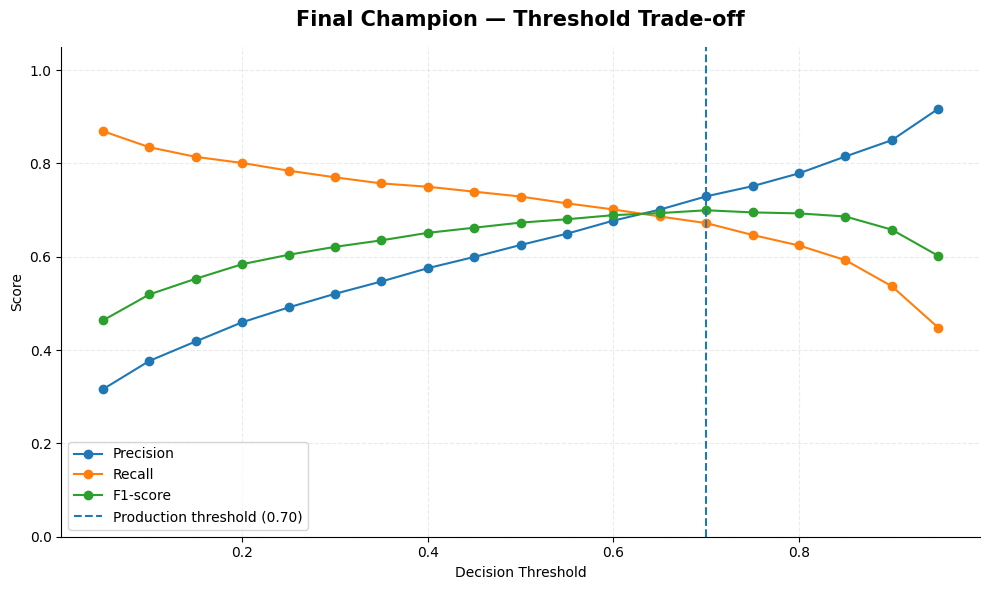

In [158]:
# ============================================================
# FINAL CHAMPION THRESHOLD TRADE-OFF
# ============================================================

final_threshold_results = analyze_thresholds(
    model=final_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

plt.figure(figsize=(10, 6))

plt.plot(
    final_threshold_results["threshold"],
    final_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    final_threshold_results["threshold"],
    final_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    final_threshold_results["threshold"],
    final_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label=f"Production threshold ({final_threshold:.2f})",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Final Champion — Threshold Trade-off",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.ylim(0, 1.05)

plt.grid(
    linestyle="--",
    alpha=0.25,
)

plt.legend()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "final_champion_threshold_tradeoff.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Validation Model Comparison

Validation PR-AUC is used as the primary comparison metric because fraud detection is a highly imbalanced classification problem.

This visualization compares the evaluated candidate models using their validation PR-AUC.

Because PR-AUC is threshold-independent, the comparison is not affected by the classification threshold used for the accompanying evaluation.

The comparison supports model selection and does not use the untouched test set.


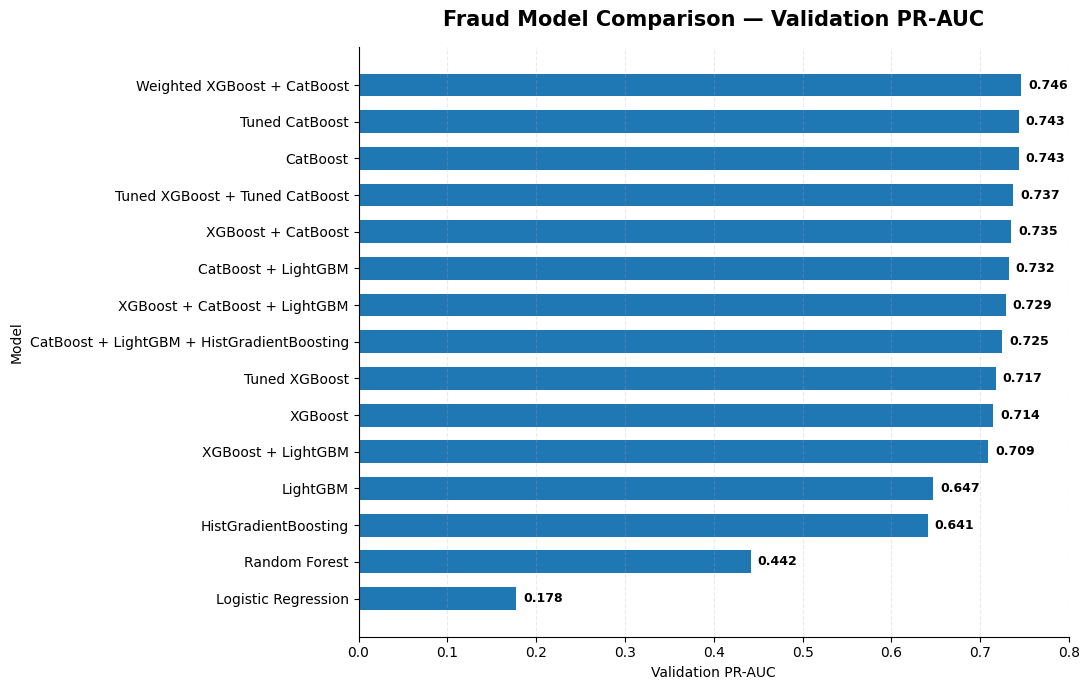

In [159]:
# ============================================================
# VALIDATION MODEL COMPARISON — PR-AUC
# ============================================================

model_comparison_rows = []

for model_name, probabilities in all_candidate_probabilities.items():
    evaluation = evaluate_probabilities(
        probabilities=probabilities,
        y=y_validation,
        threshold=0.50,
    )

    model_comparison_rows.append(
        {
            "model": model_name,
            "pr_auc": evaluation["pr_auc"],
        }
    )

model_comparison_plot = (
    pd.DataFrame(model_comparison_rows)
    .sort_values(
        "pr_auc",
        ascending=True,
    )
    .reset_index(drop=True)
)


def shorten_model_name(name):
    replacements = {
        "RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)":
            "Weighted XGBoost + CatBoost",
        "RandomizedSearch XGBoost":
            "Tuned XGBoost",
        "RandomizedSearch CatBoost":
            "Tuned CatBoost",
        "HistGradientBoosting":
            "HistGradientBoosting",
        "Logistic Regression":
            "Logistic Regression",
        "Random Forest":
            "Random Forest",
        "LightGBM":
            "LightGBM",
    }

    return replacements.get(name, name)


model_comparison_plot["display_model"] = (
    model_comparison_plot["model"]
    .map(shorten_model_name)
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    model_comparison_plot["display_model"],
    model_comparison_plot["pr_auc"],
    height=0.62,
)

for bar, value in zip(
    bars,
    model_comparison_plot["pr_auc"],
):
    plt.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.xlabel("Validation PR-AUC")
plt.ylabel("Model")
plt.title(
    "Fraud Model Comparison — Validation PR-AUC",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.xlim(0, 0.80)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "model_comparison_pr_auc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Final Model Summary

The final fraud-risk classifier was selected after comparing the evaluated baseline models, tuned models, and ensemble candidates on the validation set.

The final champion was selected primarily based on validation predictive performance, with threshold behavior and business-cost robustness used as supporting evidence.

The selected production configuration is:

- **Final champion:** RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7)
- **Production threshold:** 0.70
- **Validation PR-AUC:** 0.746
- **Validation F1-score:** 0.700
- **Lowest validation business cost:** 59,980 at threshold 0.05

The production threshold of 0.70 was frozen before evaluating the untouched test set.

The final champion was then evaluated once on the untouched test set, followed by final error analysis, feature-importance analysis, and production artifact generation.

In [160]:
print(
    f"{FINAL_MODEL_NAME} was selected as the final production model."
)

RandomizedSearch XGBoost + RandomizedSearch CatBoost (0.3/0.7) was selected as the final production model.
